# ⚽ World Cup 2026 — Predictor ML

In [ ]:
import os, pickle, joblib
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import seaborn as sns
from google.colab import drive, files
from IPython.display import display
from itertools import combinations
from tqdm.notebook import tqdm
import warnings


# Machine Learning libraries
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics         import (accuracy_score, log_loss,
                                     classification_report,
                                     ConfusionMatrixDisplay,
                                     confusion_matrix)
from sklearn.inspection      import permutation_importance
import xgboost  as xgb
import lightgbm as lgb
import joblib

!pip install -q xgboost lightgbm

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

COLORS = {'win': '#2ecc71', 'draw': '#f39c12', 'loss': '#e74c3c'}

# Phase 1 — Dataset Loading and Exploratory Data Analysis (EDA)


## 1. Dataset Storage

Due to the size of the dataset files, the data is stored in Google Drive instead of being uploaded directly to the GitHub repository.

The datasets used are:

| Dataset | Source | Content |
|---------|--------|---------|
| International football results | Kaggle — martj42 | Match results 1872–2026 |
| ELO ratings WC 2026 | Kaggle — afonsofernandescruz | Historical ELO ratings for all 48 WC teams |

Both datasets must be downloaded as `.zip` files from Kaggle and placed in Google Drive before running this notebook.

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
DRIVE_BASE = '/content/drive/MyDrive/ML/wc2026'
DATA_DIR   = os.path.join(DRIVE_BASE, 'data')

os.makedirs(DATA_DIR, exist_ok=True)

print(f'Drive mounted.')
print(f'Base path : {DRIVE_BASE}')
print(f'Data path : {DATA_DIR}')

Drive mounted.
Base path : /content/drive/MyDrive/ML/wc2026
Data path : /content/drive/MyDrive/ML/wc2026/data


In [ ]:
print('Select the ZIP files downloaded from Kaggle (you can select multiple):')
uploaded = files.upload()

# Move uploaded files to Drive and extract them
for filename, content in uploaded.items():
    zip_path = os.path.join(DRIVE_BASE, filename)

    # Save ZIP to Drive
    with open(zip_path, 'wb') as f:
        f.write(content)
    print(f'Saved: {zip_path}')

    # Extract to data/
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
        extracted = z.namelist()
        print(f'Extracted {len(extracted)} file(s): {extracted}')

print(f'\nFiles available in {DATA_DIR}:')
for f in sorted(os.listdir(DATA_DIR)):
    size_kb = os.path.getsize(os.path.join(DATA_DIR, f)) / 1024
    print(f'  {f}  ({size_kb:.1f} KB)')

Select the ZIP files downloaded from Kaggle (you can select multiple):


Saving Results-1872-2026.zip to Results-1872-2026.zip
Saving ELO-Nations.zip to ELO-Nations.zip
Saved: /content/drive/MyDrive/ML/wc2026/Results-1872-2026.zip
Extracted 4 file(s): ['former_names.csv', 'goalscorers.csv', 'results.csv', 'shootouts.csv']
Saved: /content/drive/MyDrive/ML/wc2026/ELO-Nations.zip
Extracted 2 file(s): ['README.md', 'elo_ratings_wc2026.csv']

Files available in /content/drive/MyDrive/ML/wc2026/data:
  README.md  (10.4 KB)
  elo_ratings_wc2026.csv  (450.8 KB)
  former_names.csv  (1.7 KB)
  goalscorers.csv  (3180.4 KB)
  results.csv  (3634.8 KB)
  shootouts.csv  (28.1 KB)


## 2. Loading the Data

In [ ]:
# Load the three CSVs
results    = pd.read_csv(os.path.join(DATA_DIR, 'results.csv'),    parse_dates=['date'])
shootouts  = pd.read_csv(os.path.join(DATA_DIR, 'shootouts.csv'),  parse_dates=['date'])
goalscorers = pd.read_csv(os.path.join(DATA_DIR, 'goalscorers.csv'), parse_dates=['date'])

# ELO dataset
try:
    elo_df = pd.read_csv(os.path.join(DATA_DIR, 'elo_ratings_wc2026.csv'), parse_dates=['snapshot_date'])
except FileNotFoundError:
    candidates = [f for f in os.listdir(DATA_DIR) if 'elo' in f.lower() and f.endswith('.csv')]
    if candidates:
        elo_df = pd.read_csv(os.path.join(DATA_DIR, candidates[0]), parse_dates=['snapshot_date'])
        print(f'ELO file loaded: {candidates[0]}')
    else:
        raise FileNotFoundError('No ELO CSV found — check extraction step above.')

print(f'results.csv    : {len(results):,} rows x {results.shape[1]} columns')
print(f'shootouts.csv  : {len(shootouts):,} rows')
print(f'goalscorers.csv: {len(goalscorers):,} rows')
print(f'elo ratings    : {len(elo_df):,} rows')

results.csv    : 49,437 rows x 9 columns
shootouts.csv  : 678 rows
goalscorers.csv: 47,601 rows
elo ratings    : 4,683 rows


In [ ]:
print('=== results.csv — first rows ===')
display(results.head(8))

print('\n=== Data types and null values ===')
print(results.dtypes)
print(f'\nNull values per column:\n{results.isnull().sum()}')

=== results.csv — first rows ===


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False
5,1876-03-25,Scotland,Wales,4.0,0.0,Friendly,Glasgow,Scotland,False
6,1877-03-03,England,Scotland,1.0,3.0,Friendly,London,England,False
7,1877-03-05,Wales,Scotland,0.0,2.0,Friendly,Wrexham,Wales,False



=== Data types and null values ===
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

Null values per column:
date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64


In [ ]:
print('=== ELO ratings — first rows ===')
display(elo_df.head(8))
print(f'\nColumns: {list(elo_df.columns)}')
print(f'Unique teams in ELO dataset: {elo_df["country"].nunique()}')

=== ELO ratings — first rows ===


,year,snapshot_date,country,rank,country_code,rating,rank_max,rating_max,rank_avg,rating_avg,...,matches_home,matches_away,matches_neutral,wins,losses,draws,goals_for,goals_against,confederation,is_host
0,1901,1901-12-31,England,1,EN,2013,1,2079,2,1989,...,38,35,0,46,16,11,262,102,UEFA,0
1,1901,1901-12-31,Scotland,2,SQ,1973,1,2104,1,2018,...,37,37,0,53,9,12,277,101,UEFA,0
2,1902,1902-12-31,Argentina,1,AR,2021,1,2021,1,2021,...,0,1,0,1,0,0,6,0,CONMEBOL,0
3,1902,1902-12-31,England,2,EN,1995,1,2079,2,1989,...,39,38,0,47,16,14,266,105,UEFA,0
4,1902,1902-12-31,Scotland,3,SQ,1983,1,2104,1,2017,...,39,40,0,56,9,14,293,106,UEFA,0
5,1902,1902-12-31,Austria,4,AT,1914,4,1914,4,1914,...,1,0,0,1,0,0,5,0,UEFA,0
6,1902,1902-12-31,Uruguay,6,UY,1879,4,1879,5,1879,...,1,0,0,0,1,0,0,6,CONMEBOL,0
7,1903,1903-12-31,Argentina,1,AR,2005,1,2021,1,2018,...,1,1,0,1,1,0,8,3,CONMEBOL,0



Columns: ['year', 'snapshot_date', 'country', 'rank', 'country_code', 'rating', 'rank_max', 'rating_max', 'rank_avg', 'rating_avg', 'rank_min', 'rating_min', 'matches_total', 'matches_home', 'matches_away', 'matches_neutral', 'wins', 'losses', 'draws', 'goals_for', 'goals_against', 'confederation', 'is_host']
Unique teams in ELO dataset: 48


## 3. Preprocessing

#### Match Result Column

A `result` column is added from the perspective of the home team using the following encoding:

| Value | Meaning | Numeric |
|-------|---------|---------|
| `W` | Home team wins | `2` |
| `D` | Draw | `1` |
| `L` | Home team loses | `0` |

In [ ]:
def get_result(row):
    """Returns W/D/L from the perspective of the home team."""
    if row['home_score'] > row['away_score']:
        return 'W'
    elif row['home_score'] == row['away_score']:
        return 'D'
    else:
        return 'L'

results['result']     = results.apply(get_result, axis=1)
results['result_num'] = results['result'].map({'W': 2, 'D': 1, 'L': 0})
results['year']       = results['date'].dt.year
results['total_goals']= results['home_score'] + results['away_score']

print('Result distribution (full dataset):')
dist = results['result'].value_counts()
pct  = results['result'].value_counts(normalize=True).mul(100).round(1)
for label in ['W', 'D', 'L']:
    print(f'  {label}: {dist[label]:,}  ({pct[label]}%)')

Result distribution (full dataset):
  W: 24,192  (48.9%)
  D: 11,225  (22.7%)
  L: 14,020  (28.4%)


In [ ]:
# Modern era — more relevant for predictions
results_modern = results[results['year'] >= 1990].copy()

# World Cup matches only
results_wc = results[results['tournament'] == 'FIFA World Cup'].copy()

# Competitive matches since 2010 (no friendlies)
results_competitive = results[
    (results['year'] >= 2010) &
    (~results['tournament'].str.contains('Friendly', na=False))
].copy()

print(f'Full dataset           : {len(results):>7,} matches')
print(f'Modern era (1990+)     : {len(results_modern):>7,} matches')
print(f'FIFA World Cup only    : {len(results_wc):>7,} matches')
print(f'Competitive (2010+)    : {len(results_competitive):>7,} matches')

print(f'\nTop 10 tournaments in dataset:')
print(results['tournament'].value_counts().head(10).to_string())

Full dataset           :  49,437 matches
Modern era (1990+)     :  32,319 matches
FIFA World Cup only    :   1,036 matches
Competitive (2010+)    :  10,808 matches

Top 10 tournaments in dataset:
tournament
Friendly                                18356
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620


## 4. Exploratory Data Analysis

This section analyzes the data to identify patterns and validate that the selected features will be useful for the model.

#### Sections covered:
- Result distribution (all matches vs. World Cup only)
- Goals scored over time
- Win rate of the 48 WC 2026 qualified teams
- ELO rating distribution
- Correlation between ELO and win rate (feature validation)
- Head-to-head data availability

### 4.1 Result Distribution

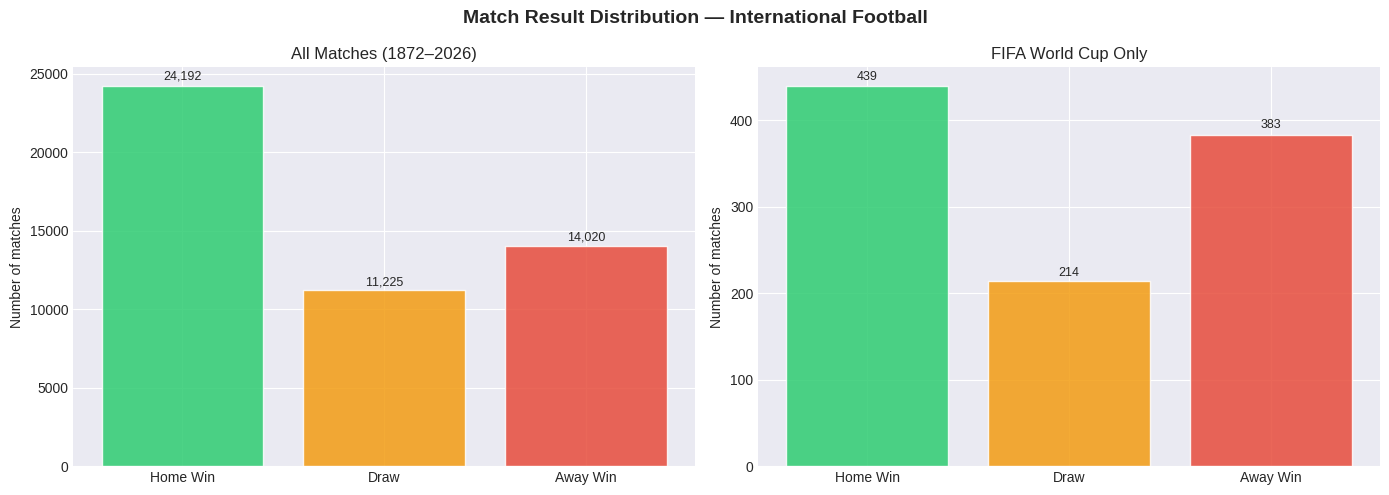

Home win rate — All matches  : 48.9%
Home win rate — World Cup    : 42.4%
Note: World Cup matches are played on neutral ground, so the home win
advantage disappears. This is an important modeling consideration.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Match Result Distribution — International Football', fontsize=14, fontweight='bold')

labels = ['Home Win', 'Draw', 'Away Win']

for ax, df, title in [
    (axes[0], results,    'All Matches (1872–2026)'),
    (axes[1], results_wc, 'FIFA World Cup Only')
]:
    counts = df['result'].value_counts()
    vals = [counts.get('W', 0), counts.get('D', 0), counts.get('L', 0)]
    bars = ax.bar(labels, vals, color=[COLORS['win'], COLORS['draw'], COLORS['loss']],
                  alpha=0.85, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Number of matches')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'result_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

wc_hw = results_wc['result'].value_counts(normalize=True)['W'] * 100
all_hw = results['result'].value_counts(normalize=True)['W'] * 100
print(f'Home win rate — All matches  : {all_hw:.1f}%')
print(f'Home win rate — World Cup    : {wc_hw:.1f}%')
print('Note: World Cup matches are played on neutral ground, so the home win')
print('advantage disappears. This is an important modeling consideration.')

### 4.2 Goals Scored Over Time

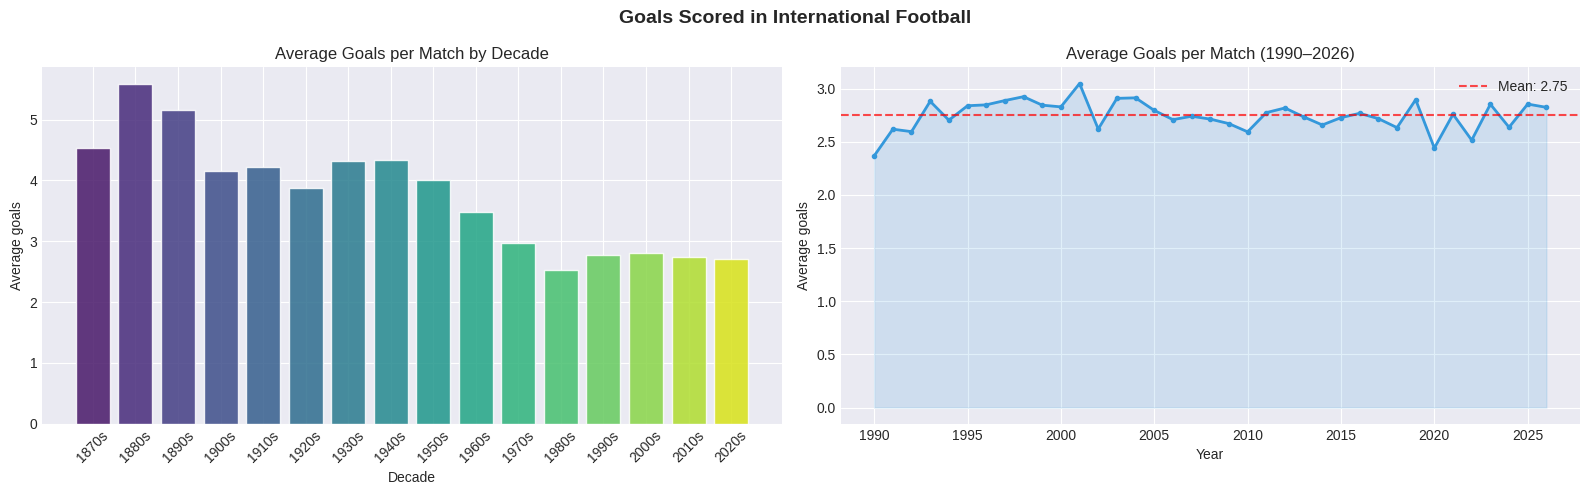

Modern era average (1990+): 2.75 goals/match


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Goals Scored in International Football', fontsize=14, fontweight='bold')

# By decade
tmp = results.copy()
tmp['decade'] = (tmp['year'] // 10 * 10).astype(str) + 's'
avg_decade = tmp.groupby('decade')['total_goals'].mean().reset_index()

axes[0].bar(avg_decade['decade'], avg_decade['total_goals'],
            color=sns.color_palette('viridis', len(avg_decade)), alpha=0.85, edgecolor='white')
axes[0].set_title('Average Goals per Match by Decade')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('Average goals')
axes[0].tick_params(axis='x', rotation=45)

# By year — modern era
goals_yr = results[results['year'] >= 1990].groupby('year')['total_goals'].mean()
axes[1].plot(goals_yr.index, goals_yr.values, color='#3498db', linewidth=2, marker='o', markersize=3)
axes[1].axhline(goals_yr.mean(), color='red', linestyle='--', alpha=0.7, label=f'Mean: {goals_yr.mean():.2f}')
axes[1].fill_between(goals_yr.index, goals_yr.values, alpha=0.15, color='#3498db')
axes[1].set_title('Average Goals per Match (1990–2026)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average goals')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'goals_over_time.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Modern era average (1990+): {goals_yr.mean():.2f} goals/match')

### 4.3 The 48 Qualified Teams

In [ ]:
# Official 2026 World Cup groups and teams
WC_2026_GROUPS = {
    'A': ['Mexico',        'South Africa', 'South Korea',  'Czech Republic'],
    'B': ['Canada',        'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil',        'Morocco',      'Haiti',        'Scotland'],
    'D': ['United States', 'Paraguay',     'Australia',    'Turkey'],
    'E': ['Germany',       'Curacao',      'Ivory Coast',  'Ecuador'],
    'F': ['Netherlands',   'Japan',        'Sweden',       'Tunisia'],
    'G': ['Belgium',       'Egypt',        'Iran',         'New Zealand'],
    'H': ['Spain',         'Cape Verde',   'Saudi Arabia', 'Uruguay'],
    'I': ['France',        'Senegal',      'Iraq',         'Norway'],
    'J': ['Argentina',     'Algeria',      'Austria',      'Jordan'],
    'K': ['Portugal',      'DR Congo',     'Uzbekistan',   'Colombia'],
    'L': ['England',       'Croatia',      'Ghana',        'Panama'],
}

WC_2026_TEAMS = list({t for group in WC_2026_GROUPS.values() for t in group})
print(f'Unique qualified teams: {len(WC_2026_TEAMS)}')

print('\nFull group draw:')
for grp, teams in WC_2026_GROUPS.items():
    print(f'  Group {grp}: {" | ".join(teams)}')

Unique qualified teams: 48

Full group draw:
  Group A: Mexico | South Africa | South Korea | Czech Republic
  Group B: Canada | Bosnia and Herzegovina | Qatar | Switzerland
  Group C: Brazil | Morocco | Haiti | Scotland
  Group D: United States | Paraguay | Australia | Turkey
  Group E: Germany | Curacao | Ivory Coast | Ecuador
  Group F: Netherlands | Japan | Sweden | Tunisia
  Group G: Belgium | Egypt | Iran | New Zealand
  Group H: Spain | Cape Verde | Saudi Arabia | Uruguay
  Group I: France | Senegal | Iraq | Norway
  Group J: Argentina | Algeria | Austria | Jordan
  Group K: Portugal | DR Congo | Uzbekistan | Colombia
  Group L: England | Croatia | Ghana | Panama


### 4.4 Historical Win Rate per Team

In [ ]:
def get_team_stats(team, df, since_year=2015):
    """Calculates historical stats for a team from both home and away matches."""
    df_f = df[df['date'].dt.year >= since_year]

    home = df_f[df_f['home_team'] == team].copy()
    home['gf'] = home['home_score']
    home['ga'] = home['away_score']
    home['res'] = home['result']

    away = df_f[df_f['away_team'] == team].copy()
    away['gf'] = away['away_score']
    away['ga'] = away['home_score']
    away['res'] = away['result'].map({'W':'L','L':'W','D':'D'})

    all_g = pd.concat([home[['date','gf','ga','res']], away[['date','gf','ga','res']]])
    if len(all_g) == 0:
        return {'team': team, 'matches':0,'wins':0,'draws':0,'losses':0,
                'win_rate':0,'avg_gf':0,'avg_ga':0,'goal_diff':0}

    n = len(all_g)
    w = (all_g['res'] == 'W').sum()
    d = (all_g['res'] == 'D').sum()
    l = (all_g['res'] == 'L').sum()
    return {
        'team': team, 'matches': n,
        'wins': w, 'draws': d, 'losses': l,
        'win_rate':  round(w / n, 3),
        'avg_gf':    round(all_g['gf'].mean(), 2),
        'avg_ga':    round(all_g['ga'].mean(), 2),
        'goal_diff': round(all_g['gf'].mean() - all_g['ga'].mean(), 2)
    }

team_stats = pd.DataFrame([get_team_stats(t, results) for t in WC_2026_TEAMS])
team_stats = team_stats.sort_values('win_rate', ascending=False).reset_index(drop=True)

print('Top 10 teams by Win Rate (2015–2026):')
display(team_stats.head(10))

Top 10 teams by Win Rate (2015–2026):


,team,matches,wins,draws,losses,win_rate,avg_gf,avg_ga,goal_diff
0,Iran,130,88,24,18,0.677,2.07,0.65,1.43
1,France,148,97,27,24,0.655,2.10,0.90,1.20
2,Belgium,139,91,24,24,0.655,2.48,0.89,1.59
3,Argentina,144,94,31,19,0.653,2.01,0.65,1.35
4,Morocco,149,97,31,21,0.651,1.77,0.51,1.26
5,Japan,152,97,25,30,0.638,2.32,0.79,1.52
6,Spain,140,89,36,15,0.636,2.38,0.76,1.62
7,Brazil,140,89,30,21,0.636,2.01,0.64,1.36
8,Senegal,145,92,35,18,0.634,1.71,0.65,1.06
9,Portugal,147,92,30,25,0.626,2.24,0.77,1.47


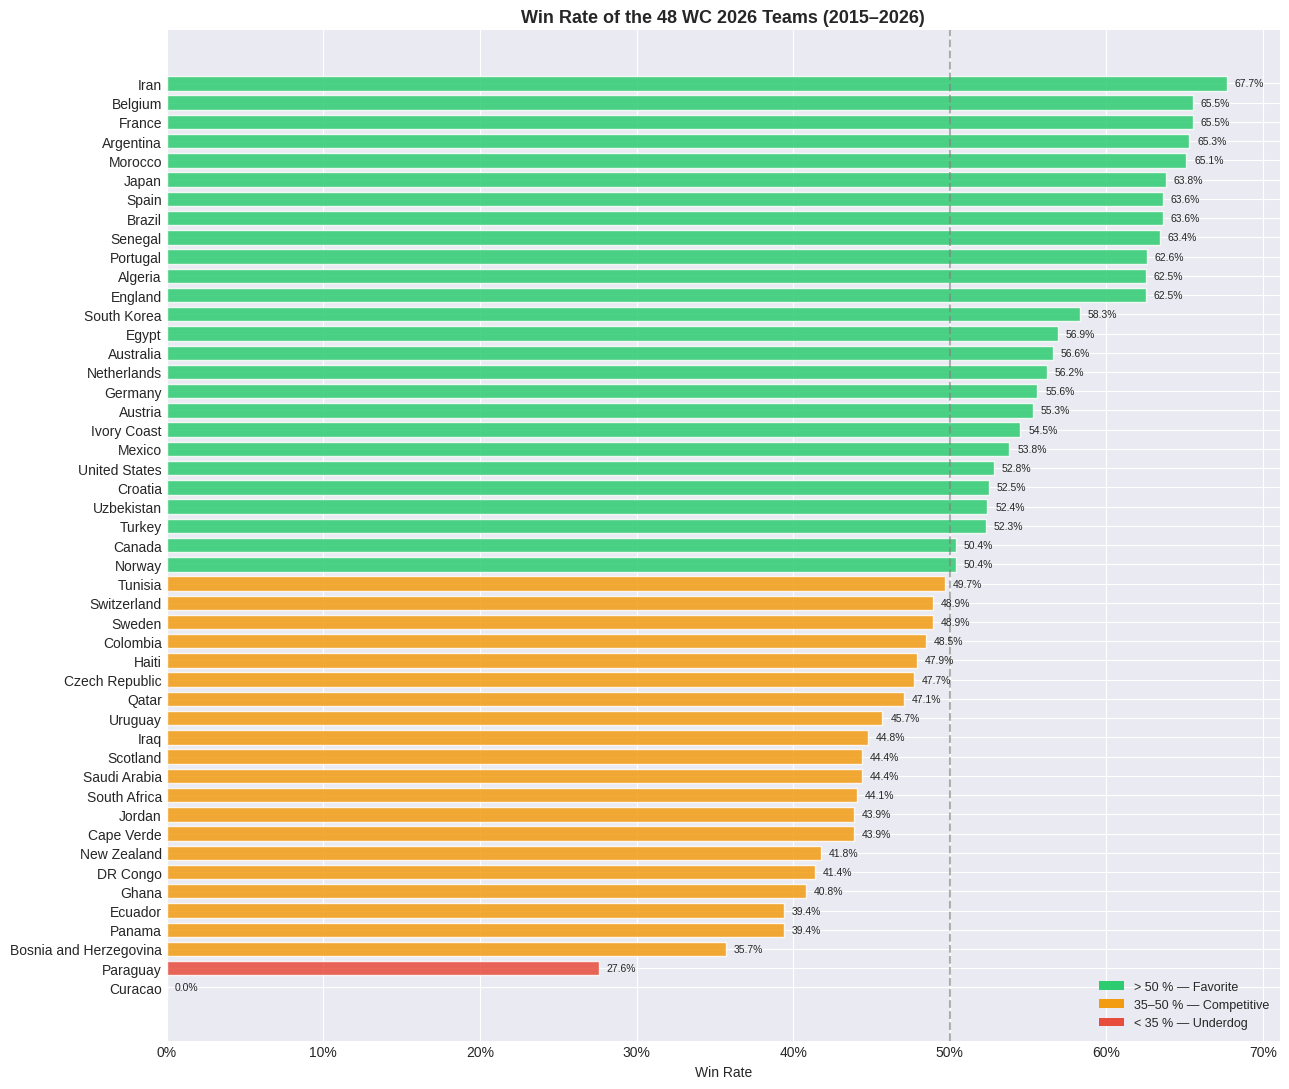

In [ ]:
fig, ax = plt.subplots(figsize=(13, 11))

ts = team_stats.sort_values('win_rate', ascending=True)
bar_colors = ['#e74c3c' if r < 0.35 else '#f39c12' if r < 0.50 else '#2ecc71'
              for r in ts['win_rate']]

bars = ax.barh(ts['team'], ts['win_rate'], color=bar_colors,
               alpha=0.85, edgecolor='white', height=0.75)
ax.axvline(0.50, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)

for bar, val in zip(bars, ts['win_rate']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', ha='left', fontsize=7.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='> 50 % — Favorite'),
    Patch(facecolor='#f39c12', label='35–50 % — Competitive'),
    Patch(facecolor='#e74c3c', label='< 35 % — Underdog'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.set_title('Win Rate of the 48 WC 2026 Teams (2015–2026)', fontsize=13, fontweight='bold')
ax.set_xlabel('Win Rate')
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'winrate_48_teams.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.5 ELO Rating Analysis

In [ ]:
# Use the most recent pre-tournament ELO snapshot
latest_snapshot = elo_df['snapshot_date'].max()
elo_latest = elo_df[elo_df['snapshot_date'] == latest_snapshot].copy()

# Filter for the 48 WC teams
# Note: team names may differ slightly between datasets
elo_wc = elo_latest[elo_latest['country'].isin(WC_2026_TEAMS)].copy()

print(f'ELO snapshot date     : {latest_snapshot.date()}')
print(f'WC teams found in ELO : {len(elo_wc)} / {len(WC_2026_TEAMS)}')

if len(elo_wc) < len(WC_2026_TEAMS):
    missing = set(WC_2026_TEAMS) - set(elo_wc['country'].tolist())
    print(f'Teams not matched     : {missing}')
    print('Tip: adjust team name spelling in WC_2026_GROUPS to match the ELO dataset.')

print('\nTop 15 by ELO Rating:')
display(elo_wc.sort_values('rating', ascending=False).head(15)[['country','rating']].reset_index(drop=True))

ELO snapshot date     : 2026-12-31
WC teams found in ELO : 46 / 48
Teams not matched     : {'Curacao', 'Czech Republic'}
Tip: adjust team name spelling in WC_2026_GROUPS to match the ELO dataset.

Top 15 by ELO Rating:


,country,rating
0,Spain,2165
1,Argentina,2113
2,France,2081
3,England,2020
4,Brazil,1984
5,Portugal,1984
6,Colombia,1975
7,Netherlands,1961
8,Ecuador,1933
9,Croatia,1930


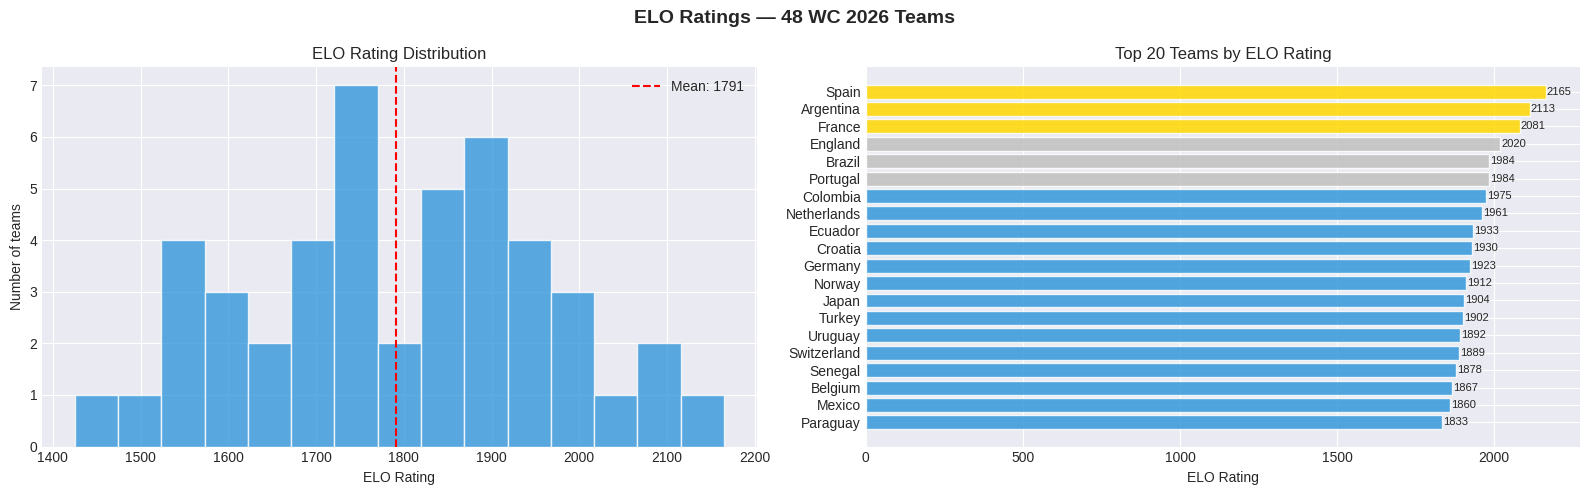

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ELO Ratings — 48 WC 2026 Teams', fontsize=14, fontweight='bold')

elo_sorted = elo_wc.sort_values('rating', ascending=False)

# Distribution
axes[0].hist(elo_sorted['rating'], bins=15, color='#3498db', alpha=0.8, edgecolor='white')
axes[0].axvline(elo_sorted['rating'].mean(), color='red', linestyle='--',
                label=f'Mean: {elo_sorted["rating"].mean():.0f}')
axes[0].set_title('ELO Rating Distribution')
axes[0].set_xlabel('ELO Rating')
axes[0].set_ylabel('Number of teams')
axes[0].legend()

# Top 20
top20 = elo_sorted.head(20)
bar_c = ['#FFD700' if i < 3 else '#C0C0C0' if i < 6 else '#3498db' for i in range(20)]
axes[1].barh(top20['country'][::-1], top20['rating'][::-1], color=bar_c[::-1], alpha=0.85, edgecolor='white')
axes[1].set_title('Top 20 Teams by ELO Rating')
axes[1].set_xlabel('ELO Rating')
for bar, val in zip(axes[1].patches, top20['rating'][::-1]):
    axes[1].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'elo_ratings.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.6 ELO vs Win Rate — Feature Validation

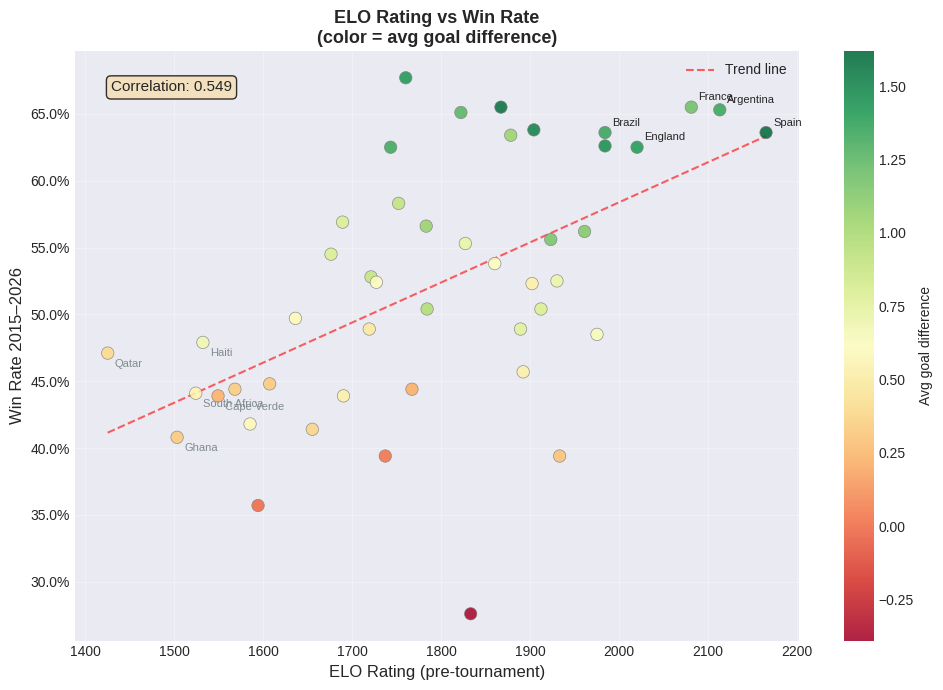

ELO vs Win Rate Pearson correlation: 0.549
A high correlation (> 0.7) confirms that ELO is a strong predictor feature.


In [ ]:
# Merge ELO with win rate to validate ELO as a useful feature
merged = pd.merge(team_stats, elo_wc[['country','rating']], left_on='team', right_on='country', how='inner')

fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(merged['rating'], merged['win_rate'],
                s=80, c=merged['goal_diff'], cmap='RdYlGn',
                alpha=0.85, edgecolors='gray', linewidth=0.5, zorder=3)
plt.colorbar(sc, label='Avg goal difference')

# Label extremes
for _, row in merged.nlargest(5, 'rating').iterrows():
    ax.annotate(row['team'], (row['rating'], row['win_rate']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)
for _, row in merged.nsmallest(5, 'rating').iterrows():
    ax.annotate(row['team'], (row['rating'], row['win_rate']),
                textcoords='offset points', xytext=(5, -10), fontsize=8, color='#7f8c8d')

# Trend line
z = np.polyfit(merged['rating'], merged['win_rate'], 1)
p = np.poly1d(z)
x_ln = np.linspace(merged['rating'].min(), merged['rating'].max(), 100)
ax.plot(x_ln, p(x_ln), 'r--', alpha=0.6, linewidth=1.5, label='Trend line')

corr = merged['rating'].corr(merged['win_rate'])
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_xlabel('ELO Rating (pre-tournament)', fontsize=12)
ax.set_ylabel('Win Rate 2015–2026', fontsize=12)
ax.set_title('ELO Rating vs Win Rate\n(color = avg goal difference)', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'elo_vs_winrate.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'ELO vs Win Rate Pearson correlation: {corr:.3f}')
print('A high correlation (> 0.7) confirms that ELO is a strong predictor feature.')

### 4.7 Head-to-Head Data Availability

In [ ]:
wc_set = set(WC_2026_TEAMS)
h2h = results[results['home_team'].isin(wc_set) & results['away_team'].isin(wc_set)]

print('Head-to-head matches between WC 2026 teams:')
print(f'  All time  : {len(h2h):,} matches')
print(f'  Since 2000: {len(h2h[h2h["year"] >= 2000]):,} matches')
print(f'  Since 2010: {len(h2h[h2h["year"] >= 2010]):,} matches')

print('\nBreakdown by tournament type (since 2010):')
print(h2h[h2h['year'] >= 2010]['tournament'].value_counts().head(10).to_string())

Head-to-head matches between WC 2026 teams:
  All time  : 7,531 matches
  Since 2000: 3,276 matches
  Since 2010: 1,979 matches

Breakdown by tournament type (since 2010):
tournament
Friendly                        819
FIFA World Cup qualification    338
FIFA World Cup                  225
UEFA Nations League             102
UEFA Euro qualification          78
African Cup of Nations           68
Copa América                     63
UEFA Euro                        59
AFC Asian Cup                    45
Gold Cup                         40


In [ ]:
import pickle
import os

checkpoint_path = os.path.join(DRIVE_BASE, 'phase1_checkpoint.pkl')

# Ensure the directory exists before saving the file
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

checkpoint = {
    'results':            results,
    'results_modern':     results_modern,
    'results_wc':         results_wc,
    'results_competitive': results_competitive,
    'shootouts':          shootouts,
    'goalscorers':        goalscorers,
    'elo_df':             elo_df,
    'elo_latest':         elo_latest,
    'team_stats':         team_stats,
    'WC_2026_TEAMS':      WC_2026_TEAMS,
    'WC_2026_GROUPS':     WC_2026_GROUPS,
    'DRIVE_BASE':         DRIVE_BASE,
    'DATA_DIR':           DATA_DIR,
}

with open(checkpoint_path, 'wb') as f:
    pickle.dump(checkpoint, f)

print(f'Checkpoint saved: {checkpoint_path}')
print('\nCheckpoint contents:')
for k, v in checkpoint.items():
    if isinstance(v, pd.DataFrame):
        print(f'  {k:<25}: DataFrame {v.shape}')
    elif isinstance(v, list):
        print(f'  {k:<25}: list of {len(v)} items')
    elif isinstance(v, dict):
        print(f'  {k:<25}: dict with {len(v)} keys')
    else:
        print(f'  {k:<25}: {type(v).__name__}')

Checkpoint saved: /content/drive/MyDrive/ML/wc2026/phase1_checkpoint.pkl

Checkpoint contents:
  results                  : DataFrame (49437, 13)
  results_modern           : DataFrame (32319, 13)
  results_wc               : DataFrame (1036, 13)
  results_competitive      : DataFrame (10808, 13)
  shootouts                : DataFrame (678, 5)
  goalscorers              : DataFrame (47601, 8)
  elo_df                   : DataFrame (4683, 23)
  elo_latest               : DataFrame (48, 23)
  team_stats               : DataFrame (48, 9)
  WC_2026_TEAMS            : list of 48 items
  WC_2026_GROUPS           : dict with 12 keys
  DRIVE_BASE               : str
  DATA_DIR                 : str


# Phase 2
**Features built in this phase:**

| Feature | Description |
|---------|-------------|
| `home_elo` / `away_elo` | Dynamic ELO rating at the moment of each match |
| `elo_diff` | Difference in ELO ratings between the two teams |
| `home_form_wr` / `away_form_wr` | Win rate over last N matches |
| `home_form_gf` / `home_form_ga` | Avg goals scored / conceded over last N matches |
| `away_form_gf` / `away_form_ga` | Avg goals scored / conceded over last N matches |
| `home_form_comp` / `away_form_comp` | Form calculated only on competitive matches |
| `h2h_home_wr` / `h2h_away_wr` | Historical head-to-head win rate between the two teams |
| `is_neutral` | Whether the match is played on neutral ground |
| `tournament_weight` | Importance weight assigned to the match type |

## 1. Load Phase 1 Checkpoint

All datasets prepared in Phase 1 are loaded from the checkpoint saved in Google Drive.

In [ ]:
DRIVE_BASE = '/content/drive/MyDrive/ML/wc2026'
checkpoint_path = os.path.join(DRIVE_BASE, 'phase1_checkpoint.pkl')

with open(checkpoint_path, 'rb') as f:
    ck = pickle.load(f)

results         = ck['results']
elo_df          = ck['elo_df']
elo_latest      = ck['elo_latest']
WC_2026_TEAMS   = ck['WC_2026_TEAMS']
WC_2026_GROUPS  = ck['WC_2026_GROUPS']

print(f'Checkpoint loaded from: {checkpoint_path}')
print(f'Results dataset: {len(results):,} matches')
print(f'Date range: {results["date"].min().date()} → {results["date"].max().date()}')

Checkpoint loaded from: /content/drive/MyDrive/ML/wc2026/phase1_checkpoint.pkl
Results dataset: 49,437 matches
Date range: 1872-11-30 → 2026-06-27


## 2. Team Name Mapping

Team names in the WC 2026 draw may differ from the names used in the historical results dataset.

This mapping ensures that every WC 2026 team can be matched against its historical records.

If names don't match, the form and head-to-head feature calculations will return empty results for those teams, producing NaN values that break the model.

In [ ]:
# Mapping: WC draw name → name used in results.csv
TEAM_NAME_MAP = {
    'Czech Republic'        : 'Czech Republic',
    'Turkey'                : 'Turkey',
    'Ivory Coast'           : 'Ivory Coast',
    'DR Congo'              : 'DR Congo',
    'Cape Verde'            : 'Cape Verde',
    'Curaçao'               : 'Curaçao',
    'United States'         : 'United States',
    'South Korea'           : 'South Korea',
    'Bosnia and Herzegovina': 'Bosnia and Herzegovina',
    'New Zealand'           : 'New Zealand',
    'Saudi Arabia'          : 'Saudi Arabia',
    'South Africa'          : 'South Africa',
}

# Find actual names in the dataset to validate the mapping
all_teams_in_dataset = set(results['home_team'].unique()) | set(results['away_team'].unique())

print('Checking team name matches:')
all_matched = True
for draw_name, dataset_name in TEAM_NAME_MAP.items():
    found = dataset_name in all_teams_in_dataset
    status = '✅' if found else '❌ NOT FOUND'
    print(f'  {status}  {draw_name!r} → {dataset_name!r}')
    if not found:
        all_matched = False
        # Suggest similar names
        similar = [t for t in all_teams_in_dataset if draw_name.lower()[:4] in t.lower()][:3]
        if similar:
            print(f'         Similar names in dataset: {similar}')

if all_matched:
    print('\n All team names matched correctly.')
else:
    print('\n Fix the names marked above in TEAM_NAME_MAP before continuing.')

Checking team name matches:
  ✅  'Czech Republic' → 'Czech Republic'
  ✅  'Turkey' → 'Turkey'
  ✅  'Ivory Coast' → 'Ivory Coast'
  ✅  'DR Congo' → 'DR Congo'
  ✅  'Cape Verde' → 'Cape Verde'
  ✅  'Curaçao' → 'Curaçao'
  ✅  'United States' → 'United States'
  ✅  'South Korea' → 'South Korea'
  ✅  'Bosnia and Herzegovina' → 'Bosnia and Herzegovina'
  ✅  'New Zealand' → 'New Zealand'
  ✅  'Saudi Arabia' → 'Saudi Arabia'
  ✅  'South Africa' → 'South Africa'

 All team names matched correctly.


In [ ]:
# Apply the mapping to normalize WC team names
def normalize_name(name):
    return TEAM_NAME_MAP.get(name, name)

# Rebuild the groups dict with normalized names
WC_2026_GROUPS_NORM = {
    grp: [normalize_name(t) for t in teams]
    for grp, teams in WC_2026_GROUPS.items()
}

WC_2026_TEAMS_NORM = list({t for g in WC_2026_GROUPS_NORM.values() for t in g})

print(f'Normalized WC teams: {len(WC_2026_TEAMS_NORM)}')
print('\nFull normalized group draw:')
for grp, teams in WC_2026_GROUPS_NORM.items():
    print(f'  Group {grp}: {" | ".join(teams)}')

Normalized WC teams: 48

Full normalized group draw:
  Group A: Mexico | South Africa | South Korea | Czech Republic
  Group B: Canada | Bosnia and Herzegovina | Qatar | Switzerland
  Group C: Brazil | Morocco | Haiti | Scotland
  Group D: United States | Paraguay | Australia | Turkey
  Group E: Germany | Curacao | Ivory Coast | Ecuador
  Group F: Netherlands | Japan | Sweden | Tunisia
  Group G: Belgium | Egypt | Iran | New Zealand
  Group H: Spain | Cape Verde | Saudi Arabia | Uruguay
  Group I: France | Senegal | Iraq | Norway
  Group J: Argentina | Algeria | Austria | Jordan
  Group K: Portugal | DR Congo | Uzbekistan | Colombia
  Group L: England | Croatia | Ghana | Panama


## 3. Tournament Importance Weights

Not all matches carry the same predictive value.

A friendly against a weak opponent reveals much less about a team's quality than a World Cup knockout match.

Tournament weights are applied in two places:
- When computing the dynamic ELO (K-factor)
- When filtering competitive vs. non-competitive form

#### Weight table

| Tournament type | Weight | K-factor |
|-----------------|--------|----------|
| FIFA World Cup | 1.0 | 60 |
| Continental championship (Copa America, Euro, AFCON, etc.) | 0.85 | 50 |
| World Cup qualifier | 0.75 | 40 |
| Confederation cup / Nations League | 0.65 | 35 |
| Friendly | 0.30 | 20 |

In [ ]:
def get_tournament_weight(tournament: str) -> float:
    """Returns an importance weight for a given tournament name."""
    t = str(tournament).lower()

    if 'fifa world cup' in t and 'qualifier' not in t:
        return 1.00   # WC final
    if any(x in t for x in ['uefa euro', 'copa america', 'africa cup', 'afcon',
                              'gold cup', 'asian cup', 'oceania']):
        return 0.85   # Continental championship
    if 'qualifier' in t or 'qualification' in t:
        return 0.75   # World Cup / continental qualifier
    if any(x in t for x in ['nations league', 'confederation', 'confederations cup']):
        return 0.65   # Secondary competition
    if 'friendly' in t:
        return 0.30   # Friendly
    return 0.50       # Default for unrecognized tournaments

def get_k_factor(tournament: str) -> int:
    """Returns the ELO K-factor for a given tournament."""
    w = get_tournament_weight(tournament)
    if w >= 1.0:  return 60
    if w >= 0.85: return 50
    if w >= 0.75: return 40
    if w >= 0.65: return 35
    if w >= 0.30: return 20
    return 30

# Apply weights to the results dataset
results['tournament_weight'] = results['tournament'].apply(get_tournament_weight)
results['k_factor']          = results['tournament'].apply(get_k_factor)

print('Tournament weight distribution:')
print(results.groupby('tournament_weight')['tournament'].agg(
    count='count',
    examples=lambda x: list(x.unique()[:2])
).reset_index().to_string(index=False))

Tournament weight distribution:
 tournament_weight  count                                                                    examples
              0.30  18356                                                                  [Friendly]
              0.50  11529                           [British Home Championship, Évence Coppée Trophy]
              0.65   1220                                   [Confederations Cup, UEFA Nations League]
              0.75   3385 [African Cup of Nations qualification, CONCACAF Championship qualification]
              0.85   5140                                [AFC Asian Cup qualification, AFC Asian Cup]
              1.00   9807                              [FIFA World Cup, FIFA World Cup qualification]


## 4. Dynamic ELO Ratings

ELO ratings are calculated match by match in chronological order.

#### Formula

```
Expected score:  Ea = 1 / (1 + 10 ^ ((Rb - Ra) / 400))
New rating:      Ra_new = Ra + K * (Sa - Ea)
```

Where:
- `Ra`, `Rb` = current ELO ratings of home and away team
- `K` = K-factor (varies by tournament importance)
- `Sa` = actual result (1 = win, 0.5 = draw, 0 = loss)

#### Why compute ELO dynamically

Using a static ELO snapshot would cause **data leakage**: the model would have access to information from the future when predicting past matches. The dynamic approach ensures that the ELO rating used to predict a match only reflects matches played before that date.

#### Starting ratings

All teams start at 1500. Teams with historical data quickly diverge from this initial value as their matches are processed.

In [ ]:
def compute_dynamic_elo(df: pd.DataFrame,
                         initial_rating: float = 1500.0,
                         goal_diff_factor: bool = True) -> pd.DataFrame:
    """
    Computes ELO ratings match by match in chronological order.

    Returns the input DataFrame with four new columns:
      home_elo_pre  — ELO of home team BEFORE this match
      away_elo_pre  — ELO of away team BEFORE this match
      home_elo_post — ELO of home team AFTER this match
      away_elo_post — ELO of away team AFTER this match
    """
    df = df.sort_values('date').reset_index(drop=True)
    ratings = {}   # team → current ELO

    home_elo_pre  = np.zeros(len(df))
    away_elo_pre  = np.zeros(len(df))
    home_elo_post = np.zeros(len(df))
    away_elo_post = np.zeros(len(df))

    for i, row in df.iterrows():
        home = row['home_team']
        away = row['away_team']
        k    = row['k_factor']

        ra = ratings.get(home, initial_rating)
        rb = ratings.get(away, initial_rating)

        # Store pre-match ratings
        home_elo_pre[i] = ra
        away_elo_pre[i] = rb

        # Expected scores
        ea = 1 / (1 + 10 ** ((rb - ra) / 400))
        eb = 1 - ea

        # Actual scores
        if row['home_score'] > row['away_score']:
            sa, sb = 1.0, 0.0
        elif row['home_score'] == row['away_score']:
            sa, sb = 0.5, 0.5
        else:
            sa, sb = 0.0, 1.0

        # Optional goal-difference multiplier (rewards dominant wins)
        if goal_diff_factor:
            gd = abs(row['home_score'] - row['away_score'])
            gd_mult = np.log(gd + 1) + 1 if gd > 0 else 1
        else:
            gd_mult = 1

        # Update ratings
        ra_new = ra + k * gd_mult * (sa - ea)
        rb_new = rb + k * gd_mult * (sb - eb)

        ratings[home] = ra_new
        ratings[away] = rb_new

        home_elo_post[i] = ra_new
        away_elo_post[i] = rb_new

    df['home_elo_pre']  = home_elo_pre
    df['away_elo_pre']  = away_elo_pre
    df['home_elo_post'] = home_elo_post
    df['away_elo_post'] = away_elo_post
    df['elo_diff']      = df['home_elo_pre'] - df['away_elo_pre']

    return df, ratings   # also return final ratings dict for WC simulation

print('Computing dynamic ELO ratings for all 50k+ matches...')
results, final_elo_ratings = compute_dynamic_elo(results)
print('Done.')
print(f'\nSample of computed ELO:')
display(results[['date','home_team','away_team','home_score','away_score',
                  'home_elo_pre','away_elo_pre','elo_diff']].head(8))

Computing dynamic ELO ratings for all 50k+ matches...
Done.

Sample of computed ELO:


,date,home_team,away_team,home_score,away_score,home_elo_pre,away_elo_pre,elo_diff
0,1872-11-30,Scotland,England,0.0,0.0,1500.000000,1500.000000,0.000000
1,1873-03-08,England,Scotland,4.0,2.0,1500.000000,1500.000000,0.000000
2,1874-03-07,Scotland,England,2.0,1.0,1479.013877,1520.986123,-41.972246
3,1875-03-06,England,Scotland,2.0,2.0,1502.019123,1497.980877,4.038246
4,1876-03-04,Scotland,England,3.0,0.0,1498.097102,1501.902898,-3.805796
5,1876-03-25,Scotland,Wales,4.0,0.0,1522.221429,1500.000000,22.221429
6,1877-03-03,England,Scotland,1.0,3.0,1477.778571,1546.649125,-68.870553
7,1877-03-05,Wales,Scotland,0.0,2.0,1475.572304,1563.528909,-87.956605


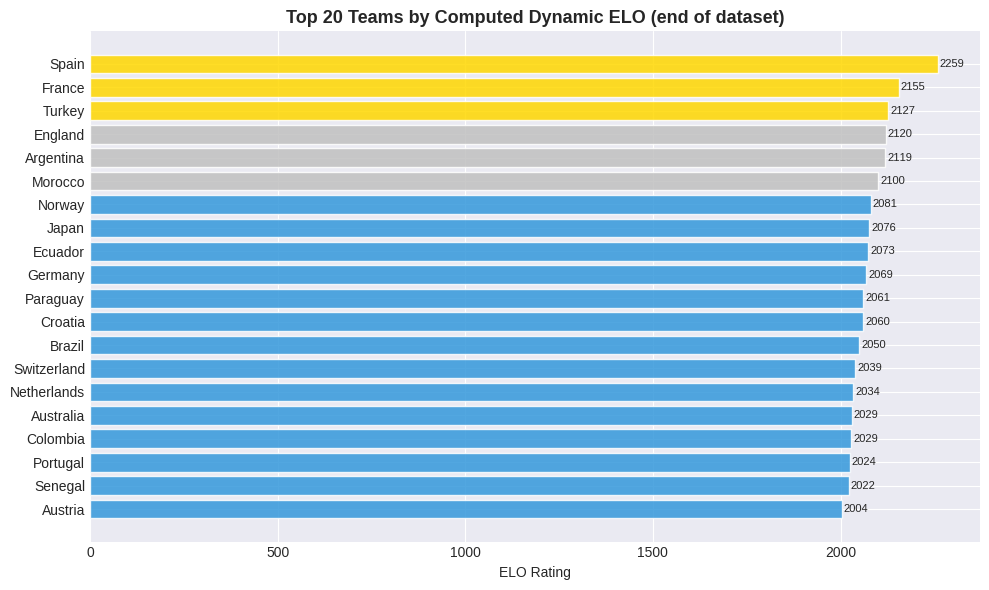


Computed ELO for WC 2026 teams (sorted):


,team,elo
0,Spain,2258.6
1,France,2154.8
2,Turkey,2127.5
3,England,2120.3
4,Argentina,2119.0
5,Morocco,2100.2
6,Norway,2080.8
7,Japan,2076.2
8,Ecuador,2073.5
9,Germany,2069.0


In [ ]:
# Validate: top teams by final ELO should match expectations
top_elos = pd.Series(final_elo_ratings).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#FFD700' if i < 3 else '#C0C0C0' if i < 6 else '#3498db'
              for i in range(len(top_elos))]
ax.barh(top_elos.index[::-1], top_elos.values[::-1],
        color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax.set_title('Top 20 Teams by Computed Dynamic ELO (end of dataset)', fontsize=13, fontweight='bold')
ax.set_xlabel('ELO Rating')
for bar, val in zip(ax.patches, top_elos.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'dynamic_elo_top20.png'), dpi=150, bbox_inches='tight')
plt.show()

# Check WC 2026 teams specifically
print('\nComputed ELO for WC 2026 teams (sorted):')
wc_elos = {t: final_elo_ratings.get(t, 1500) for t in WC_2026_TEAMS_NORM}
wc_elo_series = pd.Series(wc_elos).sort_values(ascending=False)
display(pd.DataFrame({'team': wc_elo_series.index, 'elo': wc_elo_series.values.round(1)}).head(20))

## 5. Recent Form Features

Recent form captures how a team has been performing in the N matches immediately before the match being predicted.

#### Design decisions

- Only matches **before** the current match date are included (no leakage)
- Two form windows are computed: **all matches** and **competitive only** (no friendlies)
- Friendlies are excluded from the competitive window because teams often rotate squads
- The window size is set to **10 matches** to balance recency with sample size

#### Features computed

| Feature | Description |
|---------|-------------|
| `form_wr` | Win rate in last N matches |
| `form_gf` | Average goals scored in last N matches |
| `form_ga` | Average goals conceded in last N matches |
| `form_comp_wr` | Win rate in last N competitive matches only |

In [ ]:
FORM_WINDOW = 10   # number of matches to look back

def build_team_timeline(df: pd.DataFrame) -> dict:
    """
    Builds a per-team sorted timeline of matches with results
    from both the home and away perspective.
    Returns a dict: team → sorted DataFrame of their matches.
    """
    records = []

    for _, row in df.iterrows():
        # Home perspective
        records.append({
            'team'      : row['home_team'],
            'date'      : row['date'],
            'gf'        : row['home_score'],
            'ga'        : row['away_score'],
            'result'    : row['result'],        # W/D/L already from home perspective
            'is_friendly': row['tournament_weight'] < 0.4,
        })
        # Away perspective (flip result)
        flip = {'W': 'L', 'L': 'W', 'D': 'D'}
        records.append({
            'team'      : row['away_team'],
            'date'      : row['date'],
            'gf'        : row['away_score'],
            'ga'        : row['home_score'],
            'result'    : flip[row['result']],
            'is_friendly': row['tournament_weight'] < 0.4,
        })

    timeline_df = pd.DataFrame(records).sort_values(['team', 'date'])
    return {team: grp.reset_index(drop=True)
            for team, grp in timeline_df.groupby('team')}

print('Building team timelines...')
team_timeline = build_team_timeline(results)
print(f'Done. Timelines built for {len(team_timeline)} teams.')
print(f'\nExample — last 5 matches of Argentina:')
if 'Argentina' in team_timeline:
    display(team_timeline['Argentina'].tail(5))

Building team timelines...
Done. Timelines built for 336 teams.

Example — last 5 matches of Argentina:


,team,date,gf,ga,result,is_friendly
1066,Argentina,2026-03-31,5.0,0.0,W,True
1067,Argentina,2026-06-06,2.0,0.0,W,True
1068,Argentina,2026-06-16,NaN,NaN,L,False
1069,Argentina,2026-06-22,NaN,NaN,L,False
1070,Argentina,2026-06-27,NaN,NaN,W,False


In [ ]:
def get_form(team: str, before_date, window: int = FORM_WINDOW,
              competitive_only: bool = False) -> dict:
    """
    Returns form stats for a team in the N matches before a given date.
    This guarantees no data leakage.
    """
    default = {
        'form_wr': 0.5, 'form_gf': 1.2, 'form_ga': 1.2,
        'form_comp_wr': 0.5, 'form_n': 0
    }

    if team not in team_timeline:
        return default

    history = team_timeline[team]
    past = history[history['date'] < before_date]

    if competitive_only:
        past = past[~past['is_friendly']]

    past = past.tail(window)

    if len(past) == 0:
        return default

    wins  = (past['result'] == 'W').sum()
    draws = (past['result'] == 'D').sum()
    n     = len(past)

    # Competitive-only win rate
    comp = past[~past['is_friendly']]
    comp_wr = (comp['result'] == 'W').sum() / len(comp) if len(comp) > 0 else 0.5

    return {
        'form_wr'     : float(round(wins / n, 3)),
        'form_gf'     : float(round(past['gf'].mean(), 2)),
        'form_ga'     : float(round(past['ga'].mean(), 2)),
        'form_comp_wr': float(round(comp_wr, 3)),
        'form_n'      : int(n),
    }

# Quick test
test_team = 'Brazil'
test_date = pd.Timestamp('2022-11-20')
print(f'Form of {test_team} before {test_date.date()}:')
print(get_form(test_team, test_date))

Form of Brazil before 2022-11-20:
{'form_wr': 0.8, 'form_gf': 2.8, 'form_ga': 0.3, 'form_comp_wr': 0.667, 'form_n': 10}


## 6. Head-to-Head Features

Head-to-head history captures the specific record between two teams, regardless of overall form.

#### Design decisions

- Only matches before the current match date are used (no leakage)
- Both directions of the matchup are included (home and away appearances)
- A minimum of 3 matches is required; otherwise a neutral 50/50 default is returned
- Matches are weighted by recency (more recent = more weight)

In [ ]:
H2H_WINDOW = 20   # max matches to look back for H2H

def get_h2h(team_a: str, team_b: str, before_date, window: int = H2H_WINDOW) -> dict:
    """
    Returns head-to-head stats between team_a (home perspective) and team_b.
    Only uses matches played before before_date.
    """
    default = {'h2h_a_wr': 0.5, 'h2h_b_wr': 0.5, 'h2h_n': 0}

    mask = (
        ((results['home_team'] == team_a) & (results['away_team'] == team_b)) |
        ((results['home_team'] == team_b) & (results['away_team'] == team_a))
    ) & (results['date'] < before_date)

    h2h = results[mask].sort_values('date').tail(window)

    if len(h2h) < 3:
        return default

    # Recency weights: more recent matches count more
    weights = np.linspace(0.5, 1.0, len(h2h))

    a_wins, b_wins = 0.0, 0.0
    for w, (_, row) in zip(weights, h2h.iterrows()):
        if row['home_team'] == team_a:
            if row['result'] == 'W':   a_wins += w
            elif row['result'] == 'L': b_wins += w
        else:
            if row['result'] == 'L':   a_wins += w
            elif row['result'] == 'W': b_wins += w

    total = a_wins + b_wins + weights.sum() * 0.1   # small draw weight
    return {
    'h2h_a_wr': float(round(a_wins / total, 3)),
    'h2h_b_wr': float(round(b_wins / total, 3)),
    'h2h_n'   : int(len(h2h)),
}

# Quick test
print('H2H example — Argentina vs Brazil before 2022 WC:')
print(get_h2h('Argentina', 'Brazil', pd.Timestamp('2022-11-20')))

H2H example — Argentina vs Brazil before 2022 WC:
{'h2h_a_wr': 0.364, 'h2h_b_wr': 0.524, 'h2h_n': 20}


## 7. Building the Training Dataset

Each row in the training dataset represents one match.

The features are calculated **at the time of the match** — only using information available before the match was played. This prevents data leakage.

#### Filtering strategy

- Matches used for training: **from 1995 onwards**, all tournaments
- Removing matches where either team has fewer than 5 historical matches (not enough data for features)
- Matches before 1995 are excluded because ELO ratings take time to converge from the initial 1500 value

This step is the most computationally intensive — it processes ~30,000+ matches and computes features for each one.

In [ ]:
TRAINING_START_YEAR = 1995
MIN_MATCHES_REQUIRED = 5   # minimum prior matches for a team to be included

print(f'Building training dataset from {TRAINING_START_YEAR} onwards...')

training_rows = []
train_df = results[results['year'] >= TRAINING_START_YEAR].copy()

for i, (_, row) in enumerate(train_df.iterrows()):
    if i % 5000 == 0:
        print(f'  Processing match {i:,} / {len(train_df):,}...')

    home = row['home_team']
    away = row['away_team']
    date = row['date']

    # Form features
    home_form = get_form(home, date)
    away_form = get_form(away, date)

    # Skip if either team has too little history
    if home_form['form_n'] < MIN_MATCHES_REQUIRED or away_form['form_n'] < MIN_MATCHES_REQUIRED:
        continue

    # H2H features
    h2h = get_h2h(home, away, date)

    training_rows.append({
        # --- Identifiers (not used as features) ---
        'date'              : date,
        'home_team'         : home,
        'away_team'         : away,
        'tournament'        : row['tournament'],
        'home_score'        : row['home_score'],
        'away_score'        : row['away_score'],

        # --- Target ---
        'result'            : row['result'],
        'result_num'        : row['result_num'],

        # --- ELO features ---
        'home_elo'          : round(row['home_elo_pre'], 1),
        'away_elo'          : round(row['away_elo_pre'], 1),
        'elo_diff'          : round(row['elo_diff'], 1),

        # --- Form features (all matches) ---
        'home_form_wr'      : home_form['form_wr'],
        'away_form_wr'      : away_form['form_wr'],
        'home_form_gf'      : round(home_form['form_gf'], 2),
        'home_form_ga'      : round(home_form['form_ga'], 2),
        'away_form_gf'      : round(away_form['form_gf'], 2),
        'away_form_ga'      : round(away_form['form_ga'], 2),

        # --- Competitive form ---
        'home_form_comp_wr' : home_form['form_comp_wr'],
        'away_form_comp_wr' : away_form['form_comp_wr'],

        # --- Head-to-head ---
        'h2h_home_wr'       : h2h['h2h_a_wr'],
        'h2h_away_wr'       : h2h['h2h_b_wr'],
        'h2h_n'             : h2h['h2h_n'],

        # --- Match context ---
        'is_neutral'        : int(row['neutral']),
        'tournament_weight' : row['tournament_weight'],
    })

training_data = pd.DataFrame(training_rows)
print(f'\n Training dataset built: {len(training_data):,} rows x {training_data.shape[1]} columns')

Building training dataset from 1995 onwards...
  Processing match 0 / 29,325...
  Processing match 5,000 / 29,325...
  Processing match 10,000 / 29,325...
  Processing match 15,000 / 29,325...
  Processing match 20,000 / 29,325...
  Processing match 25,000 / 29,325...

 Training dataset built: 28,966 rows x 24 columns


In [ ]:
print('Training dataset preview:')
display(training_data.head(5))

print('\nNull values per feature column:')
feature_cols = [c for c in training_data.columns
                if c not in ['date','home_team','away_team','tournament',
                              'home_score','away_score','result','result_num','h2h_n']]
print(training_data[feature_cols].isnull().sum().to_string())

print('\nFeature statistics:')
display(training_data[feature_cols].describe().round(3))

Training dataset preview:


,date,home_team,away_team,tournament,home_score,away_score,result,result_num,home_elo,away_elo,...,home_form_ga,away_form_gf,away_form_ga,home_form_comp_wr,away_form_comp_wr,h2h_home_wr,h2h_away_wr,h2h_n,is_neutral,tournament_weight
0,1995-01-01,Guinea,Sierra Leone,Friendly,3.0,1.0,W,2,1464.5,1607.1,...,1.2,1.2,1.9,0.333,0.375,0.531,0.341,18,0,0.30
1,1995-01-02,Mali,Mauritania,Friendly,0.0,1.0,L,0,1565.5,1231.2,...,1.0,0.6,1.2,0.400,0.000,0.754,0.120,16,0,0.30
2,1995-01-02,Tunisia,Egypt,Friendly,2.0,0.0,W,2,1754.1,1721.3,...,1.1,1.8,0.8,0.000,0.500,0.476,0.382,14,0,0.30
3,1995-01-04,Vietnam,Estonia,Friendly,1.0,0.0,W,2,1222.6,1087.5,...,1.8,0.1,2.7,0.200,0.000,0.500,0.500,0,0,0.30
4,1995-01-06,Saudi Arabia,Mexico,Confederations Cup,0.0,2.0,L,0,1767.0,1943.6,...,1.1,1.5,1.1,0.800,0.250,0.500,0.500,0,0,0.65



Null values per feature column:
home_elo             0
away_elo             0
elo_diff             0
home_form_wr         0
away_form_wr         0
home_form_gf         0
home_form_ga         0
away_form_gf         0
away_form_ga         0
home_form_comp_wr    0
away_form_comp_wr    0
h2h_home_wr          0
h2h_away_wr          0
is_neutral           0
tournament_weight    0

Feature statistics:


,home_elo,away_elo,elo_diff,home_form_wr,away_form_wr,home_form_gf,home_form_ga,away_form_gf,away_form_ga,home_form_comp_wr,away_form_comp_wr,h2h_home_wr,h2h_away_wr,is_neutral,tournament_weight
count,28966.000,28966.000,28966.000,28966.00,28966.000,28966.000,28966.000,28966.000,28966.000,28966.000,28966.000,28966.000,28966.000,28966.000,28966.000
mean,1622.412,1600.251,22.161,0.39,0.377,1.399,1.353,1.359,1.402,0.403,0.392,0.471,0.447,0.279,0.626
std,287.509,287.655,290.648,0.20,0.197,0.659,0.788,0.649,0.840,0.245,0.240,0.229,0.231,0.448,0.282
min,634.900,635.600,-1450.800,0.00,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.300
25%,1434.525,1421.600,-157.700,0.20,0.200,0.900,0.900,0.900,0.900,0.222,0.200,0.354,0.307,0.000,0.300
50%,1631.950,1614.150,27.600,0.40,0.400,1.300,1.200,1.300,1.200,0.400,0.400,0.500,0.500,0.000,0.500
75%,1826.800,1802.600,206.275,0.50,0.500,1.800,1.600,1.700,1.700,0.571,0.556,0.566,0.516,1.000,0.850
max,2436.000,2406.400,1404.800,1.00,1.000,8.600,14.200,7.600,14.830,1.000,1.000,0.909,0.909,1.000,1.000


## 8. Feature Analysis

Before training, we analyze the features to confirm they are informative predictors of match outcomes.

#### Sections:
- Distribution of each feature by match result
- Correlation heatmap between features and target
- ELO difference as a predictor (the most important single feature)

###  8.1 Feature distributions by result


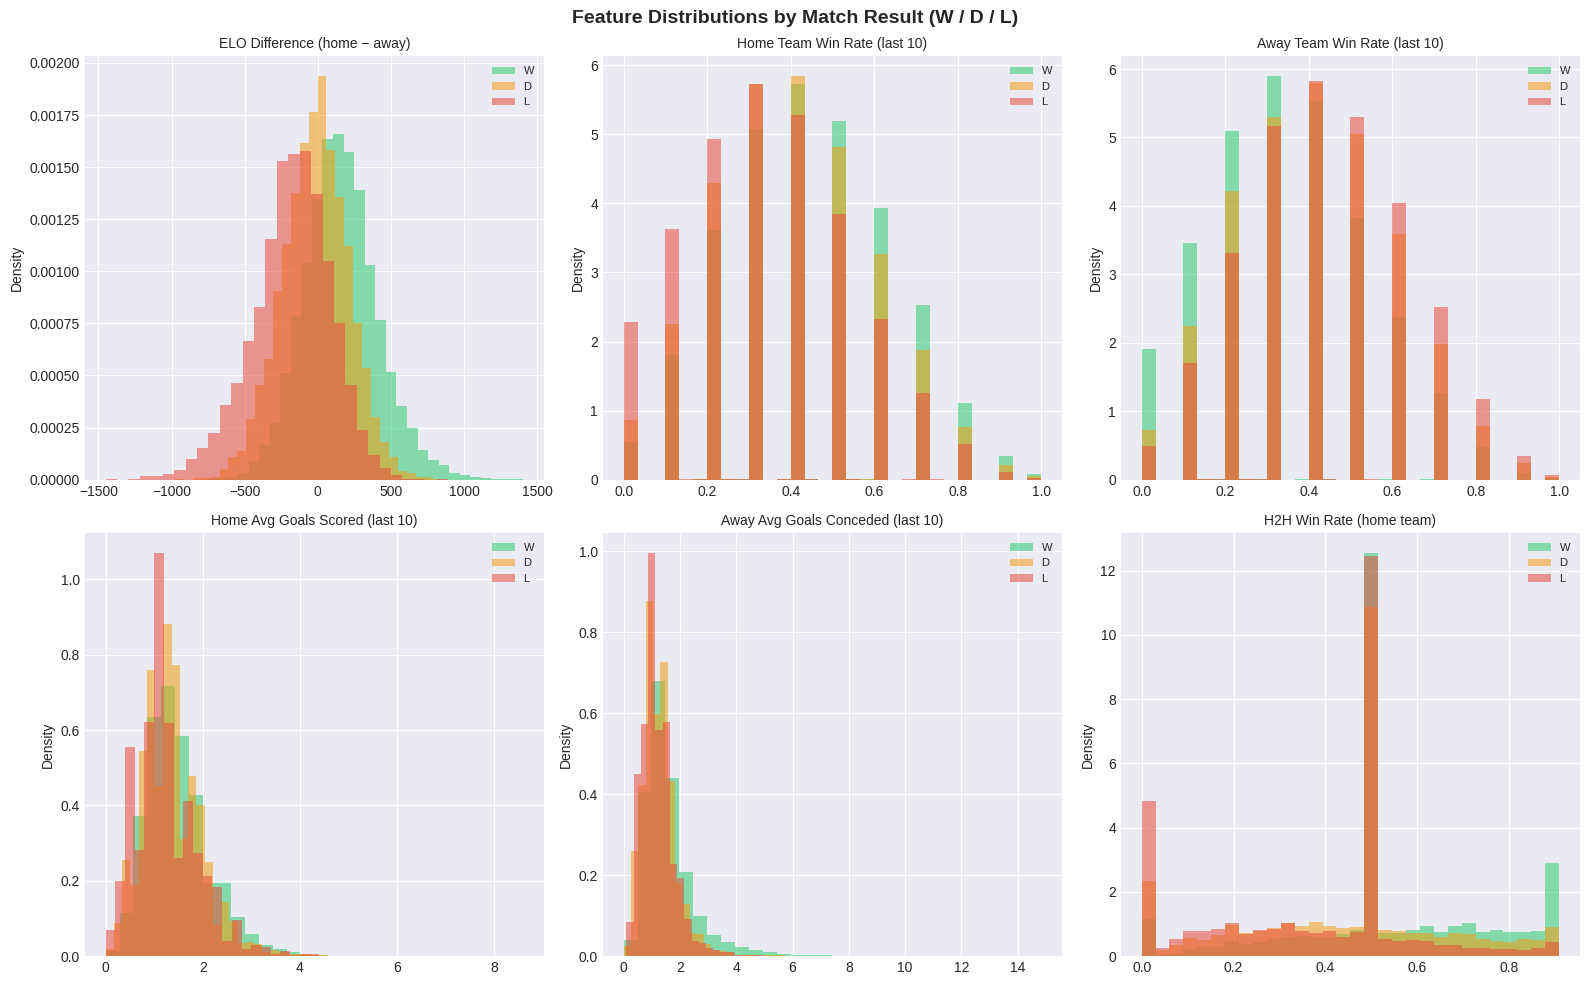

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions by Match Result (W / D / L)', fontsize=14, fontweight='bold')

features_to_plot = [
    ('elo_diff',       'ELO Difference (home − away)'),
    ('home_form_wr',   'Home Team Win Rate (last 10)'),
    ('away_form_wr',   'Away Team Win Rate (last 10)'),
    ('home_form_gf',   'Home Avg Goals Scored (last 10)'),
    ('away_form_ga',   'Away Avg Goals Conceded (last 10)'),
    ('h2h_home_wr',    'H2H Win Rate (home team)'),
]

result_colors = {'W': '#2ecc71', 'D': '#f39c12', 'L': '#e74c3c'}

for ax, (feat, label) in zip(axes.flatten(), features_to_plot):
    for res, color in result_colors.items():
        subset = training_data[training_data['result'] == res][feat].dropna()
        ax.hist(subset, bins=30, alpha=0.55, color=color, label=res, density=True)
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8.2 ELO difference vs Win probability

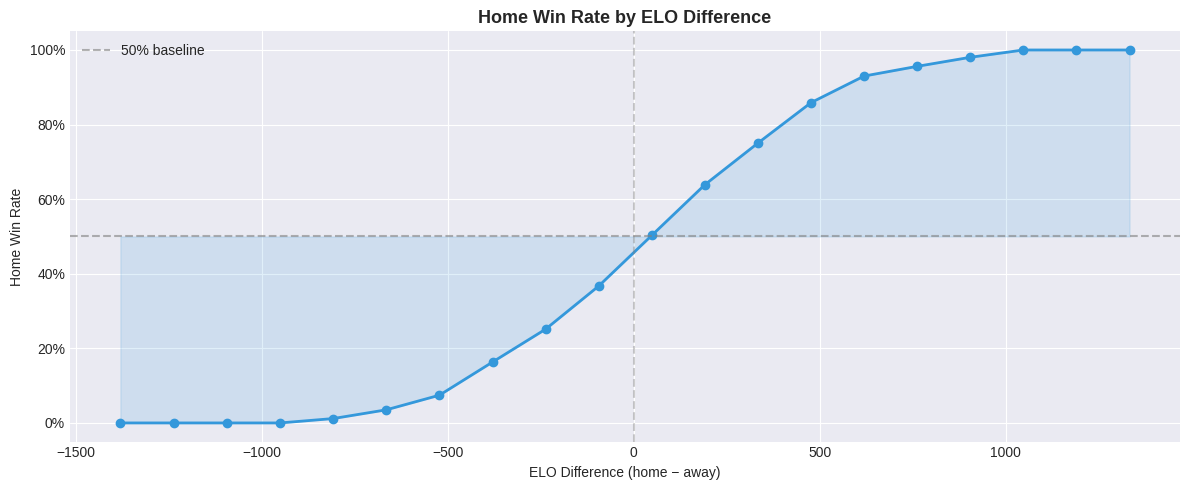

Correlation between ELO diff and home win: 0.453


In [ ]:
# Bin ELO differences and compute win rates per bin
td = training_data.copy()
td['elo_diff_bin'] = pd.cut(td['elo_diff'], bins=20)
elo_analysis = td.groupby('elo_diff_bin', observed=True)['result'].apply(
    lambda x: (x == 'W').mean()
).reset_index()
elo_analysis.columns = ['elo_diff_bin', 'home_win_rate']
elo_analysis['bin_mid'] = elo_analysis['elo_diff_bin'].apply(lambda x: x.mid)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(elo_analysis['bin_mid'], elo_analysis['home_win_rate'],
        marker='o', color='#3498db', linewidth=2, markersize=6)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='50% baseline')
ax.axvline(0,   color='gray', linestyle='--', alpha=0.4)
ax.fill_between(elo_analysis['bin_mid'], elo_analysis['home_win_rate'],
                0.5, alpha=0.15, color='#3498db')
ax.set_title('Home Win Rate by ELO Difference', fontsize=13, fontweight='bold')
ax.set_xlabel('ELO Difference (home − away)')
ax.set_ylabel('Home Win Rate')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'elo_diff_vs_winrate.png'), dpi=150, bbox_inches='tight')
plt.show()

corr = td['elo_diff'].corr((td['result'] == 'W').astype(int))
print(f'Correlation between ELO diff and home win: {corr:.3f}')

###  8.3 Correlation heatmap

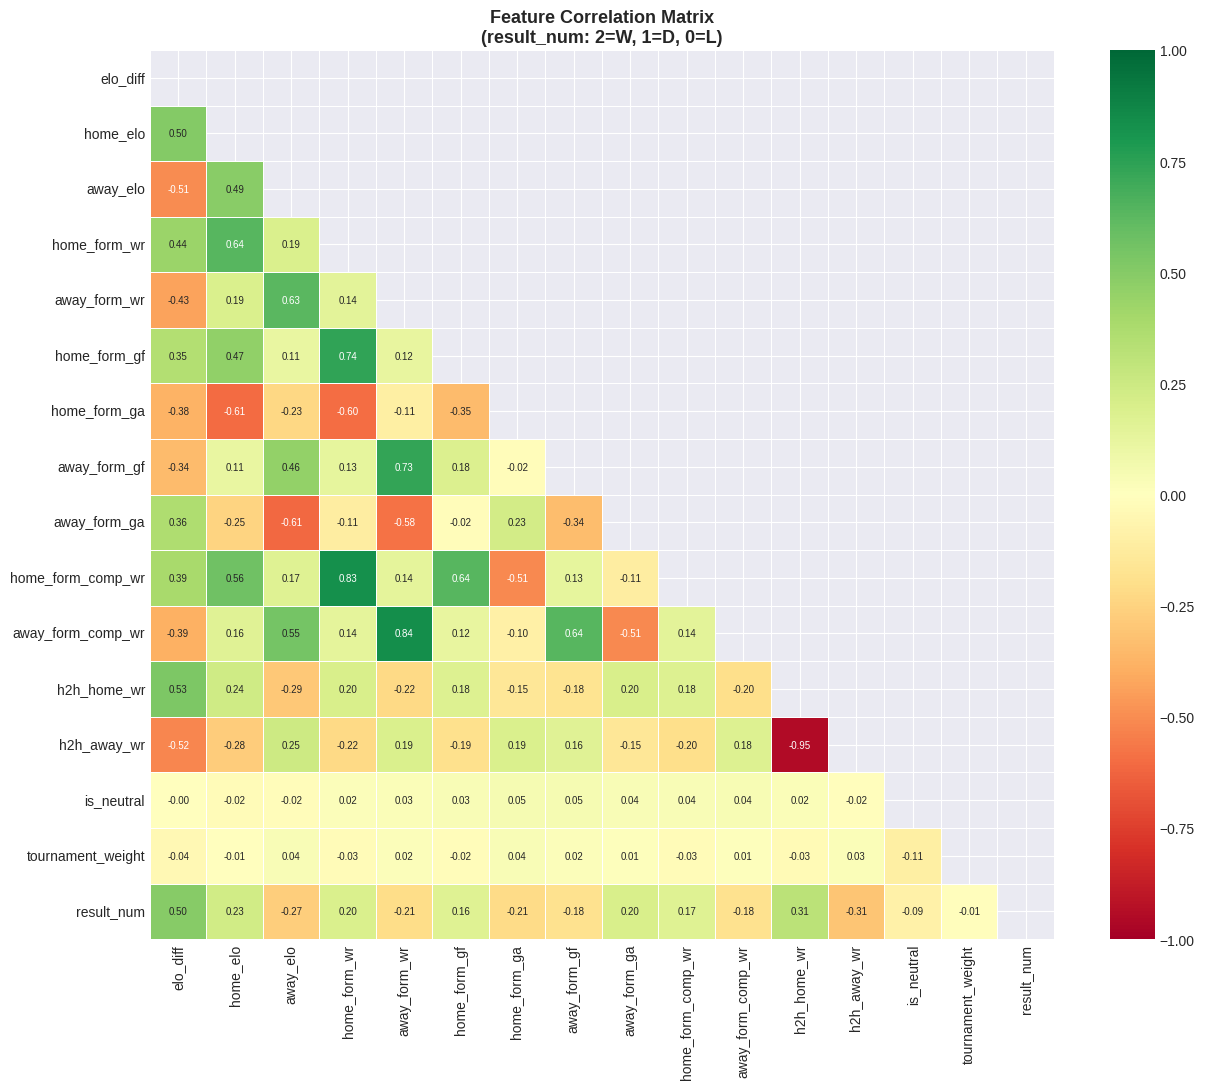

In [ ]:
feature_cols = [
    'elo_diff', 'home_elo', 'away_elo',
    'home_form_wr', 'away_form_wr',
    'home_form_gf', 'home_form_ga',
    'away_form_gf', 'away_form_ga',
    'home_form_comp_wr', 'away_form_comp_wr',
    'h2h_home_wr', 'h2h_away_wr',
    'is_neutral', 'tournament_weight',
]

corr_df = training_data[feature_cols + ['result_num']].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix\n(result_num: 2=W, 1=D, 0=L)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. WC 2026 Team Feature Snapshot

A pre-tournament feature snapshot for all 48 WC 2026 teams.

This snapshot is what will be fed into the model during tournament simulation in Phase 4.
It represents each team's state as of the last match before the tournament starts.

In [ ]:
SNAPSHOT_DATE = pd.Timestamp('2026-06-10')   # day before the tournament starts

wc_snapshots = []

for grp, teams in WC_2026_GROUPS_NORM.items():
    for team in teams:
        form = get_form(team, SNAPSHOT_DATE)
        form_comp = get_form(team, SNAPSHOT_DATE, competitive_only=True)

        wc_snapshots.append({
            'group'         : grp,
            'team'          : team,
            'elo'           : round(final_elo_ratings.get(team, 1500), 1),
            'form_wr'       : round(form['form_wr'], 3),
            'form_gf'       : round(form['form_gf'], 2),
            'form_ga'       : round(form['form_ga'], 2),
            'form_comp_wr'  : round(form_comp['form_comp_wr'], 3),
            'form_n'        : form['form_n'],
        })

wc_snapshot_df = pd.DataFrame(wc_snapshots).sort_values(['group', 'elo'], ascending=[True, False])

print('WC 2026 Team Feature Snapshot:')
display(wc_snapshot_df)

WC 2026 Team Feature Snapshot:


,group,team,elo,form_wr,form_gf,form_ga,form_comp_wr,form_n
2,A,South Korea,1989.6,0.6,1.5,1.2,0.6,10
0,A,Mexico,1948.0,0.6,1.6,0.4,0.8,10
3,A,Czech Republic,1908.2,0.5,2.2,0.9,0.5,10
1,A,South Africa,1780.1,0.5,1.5,1.0,0.5,10
7,B,Switzerland,2039.4,0.5,2.2,0.8,0.4,10
4,B,Canada,1867.3,0.4,1.1,0.4,0.6,10
5,B,Bosnia and Herzegovina,1805.9,0.3,2.0,1.0,0.5,10
6,B,Qatar,1740.1,0.1,0.7,1.5,0.3,10
9,C,Morocco,2100.2,0.7,2.2,0.3,0.8,10
8,C,Brazil,2049.7,0.6,2.5,1.1,0.4,10


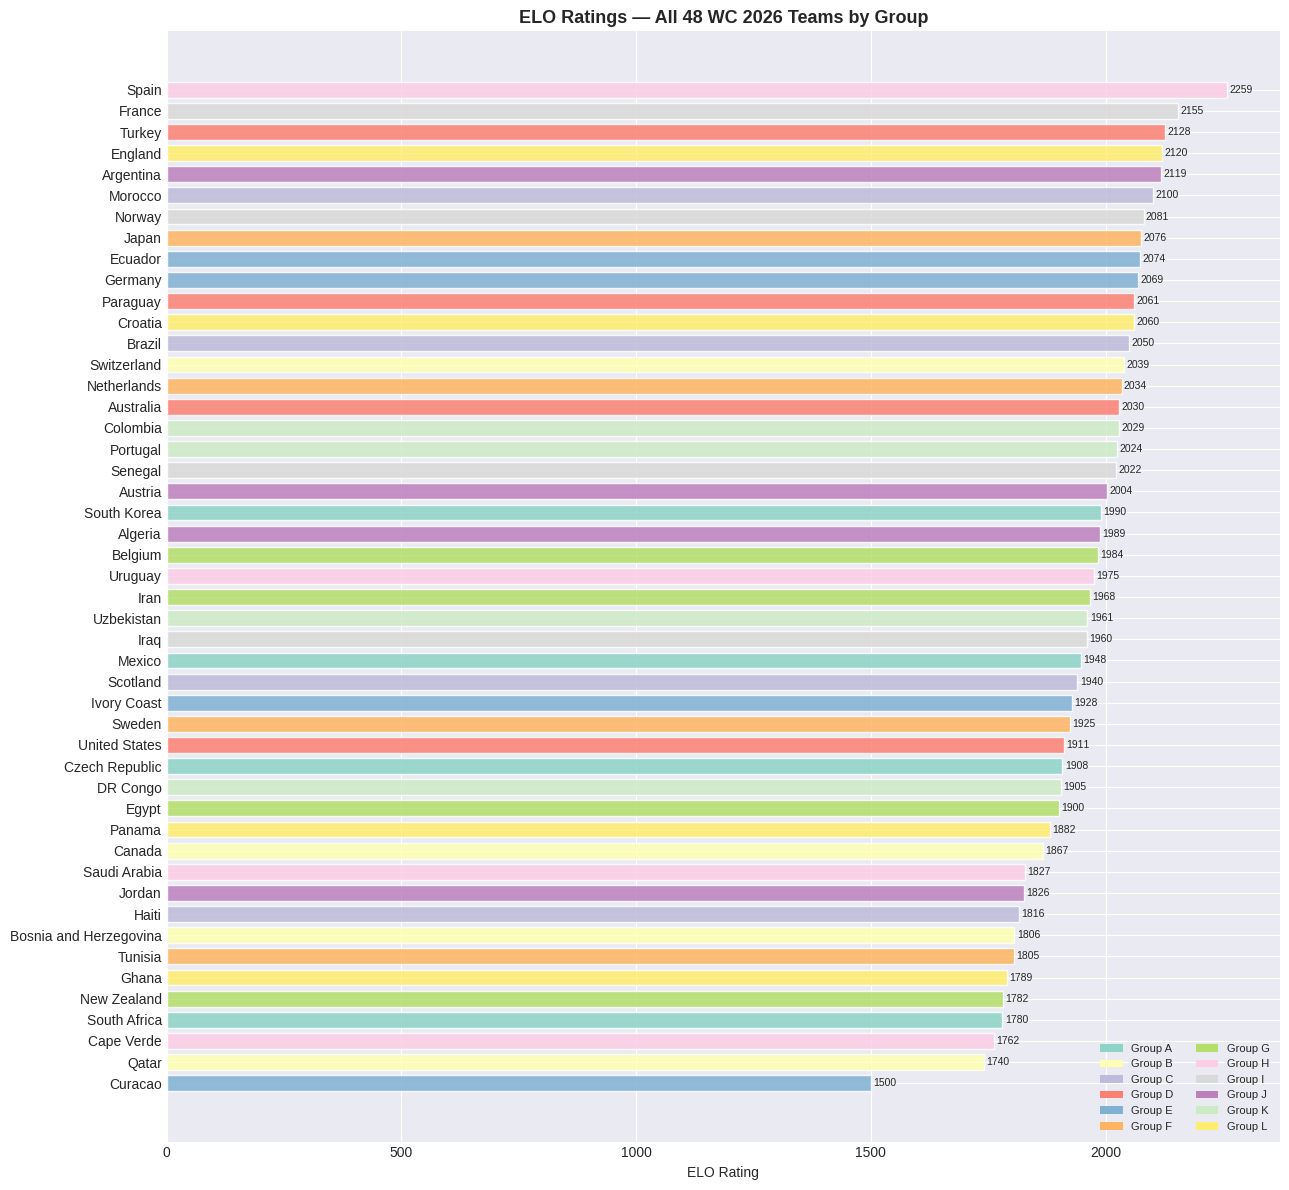

In [ ]:
# Visualize ELO snapshot for the 48 teams sorted by group
fig, ax = plt.subplots(figsize=(13, 12))

snap_sorted = wc_snapshot_df.sort_values('elo', ascending=True)
group_colors = plt.cm.Set3(np.linspace(0, 1, 12))
group_color_map = {g: group_colors[i] for i, g in enumerate('ABCDEFGHIJKL')}
bar_colors = [group_color_map[g] for g in snap_sorted['group']]

bars = ax.barh(snap_sorted['team'], snap_sorted['elo'],
               color=bar_colors, alpha=0.85, edgecolor='white', height=0.75)

for bar, val in zip(bars, snap_sorted['elo']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', ha='left', fontsize=7.5)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=group_color_map[g], label=f'Group {g}')
              for g in 'ABCDEFGHIJKL']
ax.legend(handles=legend_els, loc='lower right', ncol=2, fontsize=8)
ax.set_title('ELO Ratings — All 48 WC 2026 Teams by Group', fontsize=13, fontweight='bold')
ax.set_xlabel('ELO Rating')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'wc_team_snapshot.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
checkpoint2_path = os.path.join(DRIVE_BASE, 'phase2_checkpoint.pkl')

checkpoint2 = {
    # From Phase 1
    'results'           : results,
    'WC_2026_TEAMS_NORM': WC_2026_TEAMS_NORM,
    'WC_2026_GROUPS_NORM': WC_2026_GROUPS_NORM,
    'TEAM_NAME_MAP'     : TEAM_NAME_MAP,
    'DRIVE_BASE'        : DRIVE_BASE,

    # Phase 2 outputs
    'training_data'     : training_data,
    'wc_snapshot_df'    : wc_snapshot_df,
    'final_elo_ratings' : final_elo_ratings,
    'team_timeline'     : team_timeline,
    'FORM_WINDOW'       : FORM_WINDOW,
    'H2H_WINDOW'        : H2H_WINDOW,
    'SNAPSHOT_DATE'     : SNAPSHOT_DATE,
}

with open(checkpoint2_path, 'wb') as f:
    pickle.dump(checkpoint2, f)

print(f' Phase 2 checkpoint saved: {checkpoint2_path}')
print('\nCheckpoint contents:')
for k, v in checkpoint2.items():
    if isinstance(v, pd.DataFrame):
        print(f'  {k:<25}: DataFrame {v.shape}')
    elif isinstance(v, dict):
        print(f'  {k:<25}: dict with {len(v)} keys')
    else:
        print(f'  {k:<25}: {type(v).__name__}')


 Phase 2 checkpoint saved: /content/drive/MyDrive/ML/wc2026/phase2_checkpoint.pkl

Checkpoint contents:
  results                  : DataFrame (49437, 20)
  WC_2026_TEAMS_NORM       : list
  WC_2026_GROUPS_NORM      : dict with 12 keys
  TEAM_NAME_MAP            : dict with 12 keys
  DRIVE_BASE               : str
  training_data            : DataFrame (28966, 24)
  wc_snapshot_df           : DataFrame (48, 8)
  final_elo_ratings        : dict with 336 keys
  team_timeline            : dict with 336 keys
  FORM_WINDOW              : int
  H2H_WINDOW               : int
  SNAPSHOT_DATE            : Timestamp


# Phase 3 — Model Training and Evaluation
**Models trained in this phase:**

| Model | Type | Role |
|-------|------|------|
| Logistic Regression | Linear | Baseline |
| Random Forest | Ensemble (bagging) | Intermediate |
| XGBoost | Ensemble (boosting) | Main candidate |
| LightGBM | Ensemble (boosting) | Main candidate |

## 1. Load Phase 2 Checkpoint

In [ ]:
drive.mount('/content/drive')

DRIVE_BASE = '/content/drive/MyDrive/ML/wc2026'

with open(os.path.join(DRIVE_BASE, 'phase2_checkpoint.pkl'), 'rb') as f:
    ck = pickle.load(f)

training_data       = ck['training_data']
wc_snapshot_df      = ck['wc_snapshot_df']
final_elo_ratings   = ck['final_elo_ratings']
WC_2026_GROUPS_NORM = ck['WC_2026_GROUPS_NORM']
WC_2026_TEAMS_NORM  = ck['WC_2026_TEAMS_NORM']

print(f'Training dataset: {len(training_data):,} rows x {training_data.shape[1]} columns')
print(f'Date range: {training_data["date"].min().date()} → {training_data["date"].max().date()}')
print(f'\nResult distribution:')
print(training_data['result'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training dataset: 28,966 rows x 24 columns
Date range: 1995-01-01 → 2026-06-27

Result distribution:
result
W    14000
L     8208
D     6758
Name: count, dtype: int64


## 2. Feature Selection

The features used for training are defined here.

Identifier columns (`date`, `home_team`, `away_team`, `tournament`, scores) are excluded from the feature matrix — they are only used for splitting and analysis.

The target variable is `result_num`:

| Value | Meaning |
|-------|---------|
| `2` | Home team wins |
| `1` | Draw |
| `0` | Away team wins |

In [ ]:
FEATURE_COLS = [
    # ELO strength
    'home_elo', 'away_elo', 'elo_diff',

    # Recent form — all matches
    'home_form_wr', 'away_form_wr',
    'home_form_gf', 'home_form_ga',
    'away_form_gf', 'away_form_ga',

    # Recent form — competitive only
    'home_form_comp_wr', 'away_form_comp_wr',

    # Head-to-head
    'h2h_home_wr', 'h2h_away_wr',

    # Match context
    'is_neutral', 'tournament_weight',
]

TARGET_COL = 'result_num'
LABEL_MAP  = {2: 'Home Win', 1: 'Draw', 0: 'Away Win'}

X = training_data[FEATURE_COLS].copy()
y = training_data[TARGET_COL].copy()

print(f'Feature matrix shape : {X.shape}')
print(f'Target distribution  :')
for val, label in LABEL_MAP.items():
    n   = (y == val).sum()
    pct = n / len(y) * 100
    print(f'  {val} ({label:<12}): {n:,}  ({pct:.1f}%)')

print(f'\nNull values in features: {X.isnull().sum().sum()}')

Feature matrix shape : (28966, 15)
Target distribution  :
  2 (Home Win    ): 14,000  (48.3%)
  1 (Draw        ): 6,758  (23.3%)
  0 (Away Win    ): 8,208  (28.3%)

Null values in features: 0


## 3. Time-Based Train / Test Split

A **time-based split** is used instead of a random split.

This simulates the real-world condition where the model is trained on historical data and evaluated on more recent matches it has never seen.

Using a random split would allow information from future matches to leak into training (for example, learning patterns from a 2020 match while predicting a 2019 match), which would produce artificially inflated accuracy.

#### Split strategy

- Training set: all matches up to **December 31, 2021**
- Test set: all matches from **January 1, 2022** onward (includes 2022 WC and recent matches)

In [ ]:
SPLIT_DATE = pd.Timestamp('2022-01-01')

train_mask = training_data['date'] < SPLIT_DATE
test_mask  = training_data['date'] >= SPLIT_DATE

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Training set : {len(X_train):,} matches  ({training_data[train_mask]["date"].min().date()} → {training_data[train_mask]["date"].max().date()})')
print(f'Test set     : {len(X_test):,} matches  ({training_data[test_mask]["date"].min().date()} → {training_data[test_mask]["date"].max().date()})')

# Class distribution in each set
print(f'\nClass distribution — Train:')
for val, label in LABEL_MAP.items():
    n = (y_train == val).sum()
    print(f'  {label:<12}: {n:,}  ({n/len(y_train)*100:.1f}%)')

print(f'\nClass distribution — Test:')
for val, label in LABEL_MAP.items():
    n = (y_test == val).sum()
    print(f'  {label:<12}: {n:,}  ({n/len(y_test)*100:.1f}%)')

Training set : 24,387 matches  (1995-01-01 → 2021-12-31)
Test set     : 4,579 matches  (2022-01-01 → 2026-06-27)

Class distribution — Train:
  Home Win    : 11,850  (48.6%)
  Draw        : 5,721  (23.5%)
  Away Win    : 6,816  (27.9%)

Class distribution — Test:
  Home Win    : 2,150  (47.0%)
  Draw        : 1,037  (22.6%)
  Away Win    : 1,392  (30.4%)


## 4. Model Definitions

Four models are defined and trained.

#### Why these four models

- **Logistic Regression**: linear baseline. If it performs well, the problem might be simpler than expected. If it performs poorly, non-linear patterns are important.
- **Random Forest**: handles non-linear interactions between features, robust to noise, easy to interpret via feature importance.
- **XGBoost / LightGBM**: gradient boosting methods that typically outperform Random Forest on tabular data. LightGBM is faster and often comparable in accuracy.

#### Note on class weights

The three outcomes (Win / Draw / Loss) are not equally frequent. `class_weight='balanced'` is set for Logistic Regression and Random Forest to avoid the model ignoring the minority class (draws).

In [ ]:
# Model definitions

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
            multi_class='multinomial',
            max_iter=1000,
            class_weight='balanced',
            random_state=42,
        ))
    ]),

    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1,
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
}

print('Models defined:')
for name in models:
    print(f' {name}')

Models defined:
 Logistic Regression
 Random Forest
 XGBoost
 LightGBM


## 5. Training and Cross-Validation

Each model is evaluated with **TimeSeriesSplit** cross-validation (5 folds) on the training set before measuring final performance on the test set.

TimeSeriesSplit ensures that in each fold, the validation data is always more recent than the training data — consistent with the time-based split philosophy.

#### Metrics used

| Metric | Description |
|--------|-------------|
| **Accuracy** | Percentage of correctly predicted outcomes |
| **Log-Loss** | Penalizes confident wrong predictions. Lower is better. A random model scores ~1.10 |

In [ ]:
results_summary = []
trained_models  = {}
tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    print(f'Training {name}...')

    # Cross-validation on train set
    cv_acc = cross_val_score(model, X_train, y_train,
                             cv=tscv, scoring='accuracy', n_jobs=-1)
    cv_ll  = cross_val_score(model, X_train, y_train,
                             cv=tscv, scoring='neg_log_loss', n_jobs=-1)

    # Final fit on full training set
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Evaluation on test set
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)

    test_acc = accuracy_score(y_test, y_pred)
    test_ll  = log_loss(y_test, y_pred_prob)

    results_summary.append({
        'Model'            : name,
        'CV Accuracy (mean)': round(cv_acc.mean(), 4),
        'CV Accuracy (std)' : round(cv_acc.std(),  4),
        'CV Log-Loss (mean)': round(-cv_ll.mean(), 4),
        'Test Accuracy'     : round(test_acc,       4),
        'Test Log-Loss'     : round(test_ll,         4),
    })

    print(f'  CV Accuracy : {cv_acc.mean():.3f} ± {cv_acc.std():.3f}')
    print(f'  Test Acc    : {test_acc:.3f}   |   Test Log-Loss: {test_ll:.3f}\n')

results_df = pd.DataFrame(results_summary).sort_values('Test Accuracy', ascending=False)
print('=== Results Summary ===')
display(results_df.reset_index(drop=True))

Training Logistic Regression...
  CV Accuracy : 0.553 ± 0.016
  Test Acc    : 0.562   |   Test Log-Loss: 0.910

Training Random Forest...
  CV Accuracy : 0.551 ± 0.013
  Test Acc    : 0.565   |   Test Log-Loss: 0.914

Training XGBoost...
  CV Accuracy : 0.574 ± 0.014
  Test Acc    : 0.595   |   Test Log-Loss: 0.892

Training LightGBM...
  CV Accuracy : 0.534 ± 0.013
  Test Acc    : 0.550   |   Test Log-Loss: 0.922

=== Results Summary ===


,Model,CV Accuracy (mean),CV Accuracy (std),CV Log-Loss (mean),Test Accuracy,Test Log-Loss
0,XGBoost,0.5744,0.0138,0.9164,0.5949,0.8916
1,Random Forest,0.5512,0.0131,0.9315,0.5650,0.9137
2,Logistic Regression,0.5530,0.0162,0.9269,0.5621,0.9097
3,LightGBM,0.5338,0.0126,0.9515,0.5497,0.9215


## 6. Model Comparison

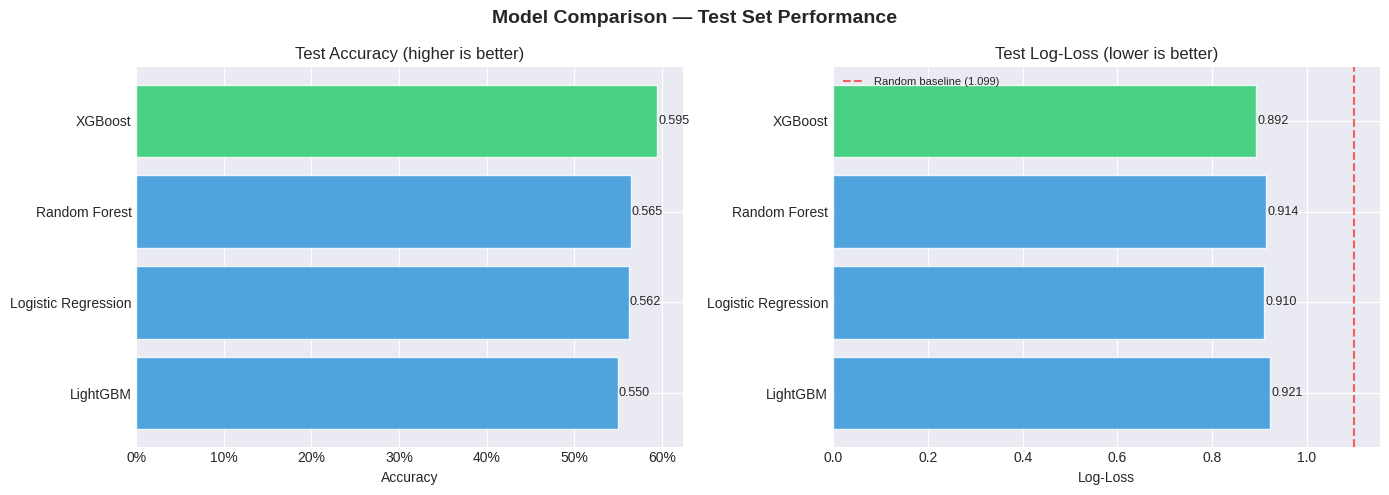

Best model by Test Accuracy: XGBoost


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison — Test Set Performance', fontsize=14, fontweight='bold')

bar_colors = ['#2ecc71' if i == 0 else '#3498db'
              for i in range(len(results_df))]

# Accuracy
axes[0].barh(results_df['Model'][::-1], results_df['Test Accuracy'][::-1],
             color=bar_colors[::-1], alpha=0.85, edgecolor='white')
axes[0].set_title('Test Accuracy (higher is better)')
axes[0].set_xlabel('Accuracy')
axes[0].xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
for bar, val in zip(axes[0].patches, results_df['Test Accuracy'][::-1]):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Log-Loss (lower is better — invert bars)
axes[1].barh(results_df['Model'][::-1], results_df['Test Log-Loss'][::-1],
             color=bar_colors[::-1], alpha=0.85, edgecolor='white')
axes[1].set_title('Test Log-Loss (lower is better)')
axes[1].set_xlabel('Log-Loss')
axes[1].axvline(1.099, color='red', linestyle='--', alpha=0.6, label='Random baseline (1.099)')
axes[1].legend(fontsize=8)
for bar, val in zip(axes[1].patches, results_df['Test Log-Loss'][::-1]):
    axes[1].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f'Best model by Test Accuracy: {best_model_name}')

## 7. Confusion Matrices

A confusion matrix shows where the model makes mistakes across the three outcome classes.

The rows represent the true outcome and the columns represent what the model predicted.

In football prediction, draws are notoriously difficult to predict — a high number of draws misclassified as wins or losses is expected.


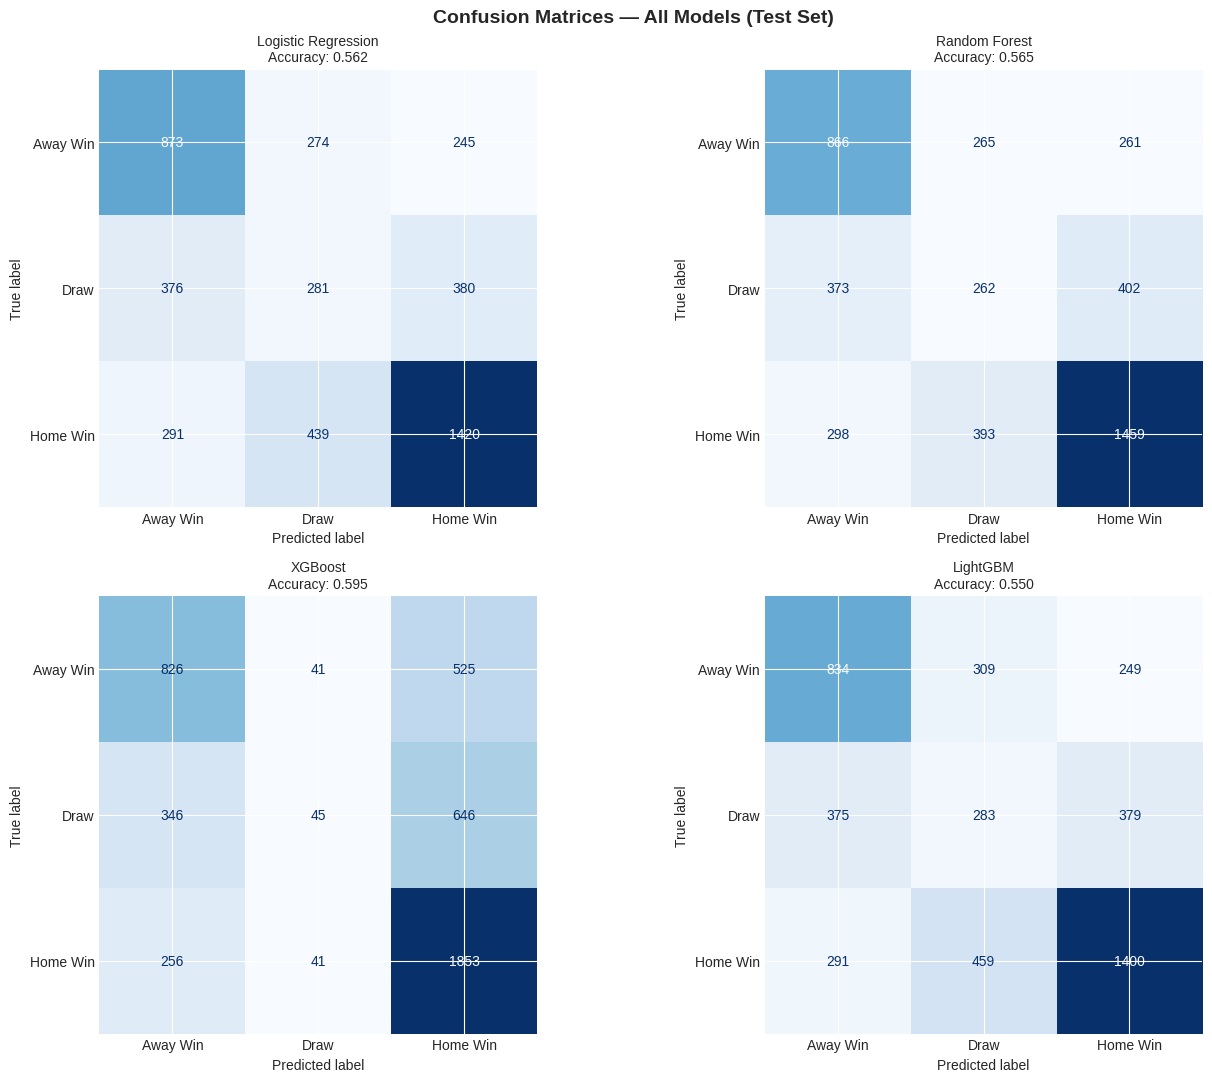

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold')
axes = axes.flatten()

class_labels = ['Away Win', 'Draw', 'Home Win']

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.3f}', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Detailed Classification Report

Per-class precision, recall and F1-score for the best model.

| Metric | Description |
|--------|-------------|
| **Precision** | Of all matches predicted as X, what fraction actually were X |
| **Recall** | Of all matches that were X, what fraction did the model correctly identify |
| **F1** | Harmonic mean of precision and recall |

In [ ]:
best_model = trained_models[best_model_name]
y_pred     = best_model.predict(X_test)

print(f'Classification Report — {best_model_name} (Test Set)')
print('=' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Away Win', 'Draw', 'Home Win']))

Classification Report — XGBoost (Test Set)
              precision    recall  f1-score   support

    Away Win       0.58      0.59      0.59      1392
        Draw       0.35      0.04      0.08      1037
    Home Win       0.61      0.86      0.72      2150

    accuracy                           0.59      4579
   macro avg       0.52      0.50      0.46      4579
weighted avg       0.54      0.59      0.53      4579



## 9. Feature Importance

Feature importance reveals which inputs have the most influence on the model's predictions.

Two methods are shown:
- **Model-native importance** (for tree-based models): based on how often and how much each feature is used to split the data
- **Permutation importance**: measures the drop in accuracy when a feature's values are randomly shuffled. More reliable but slower.

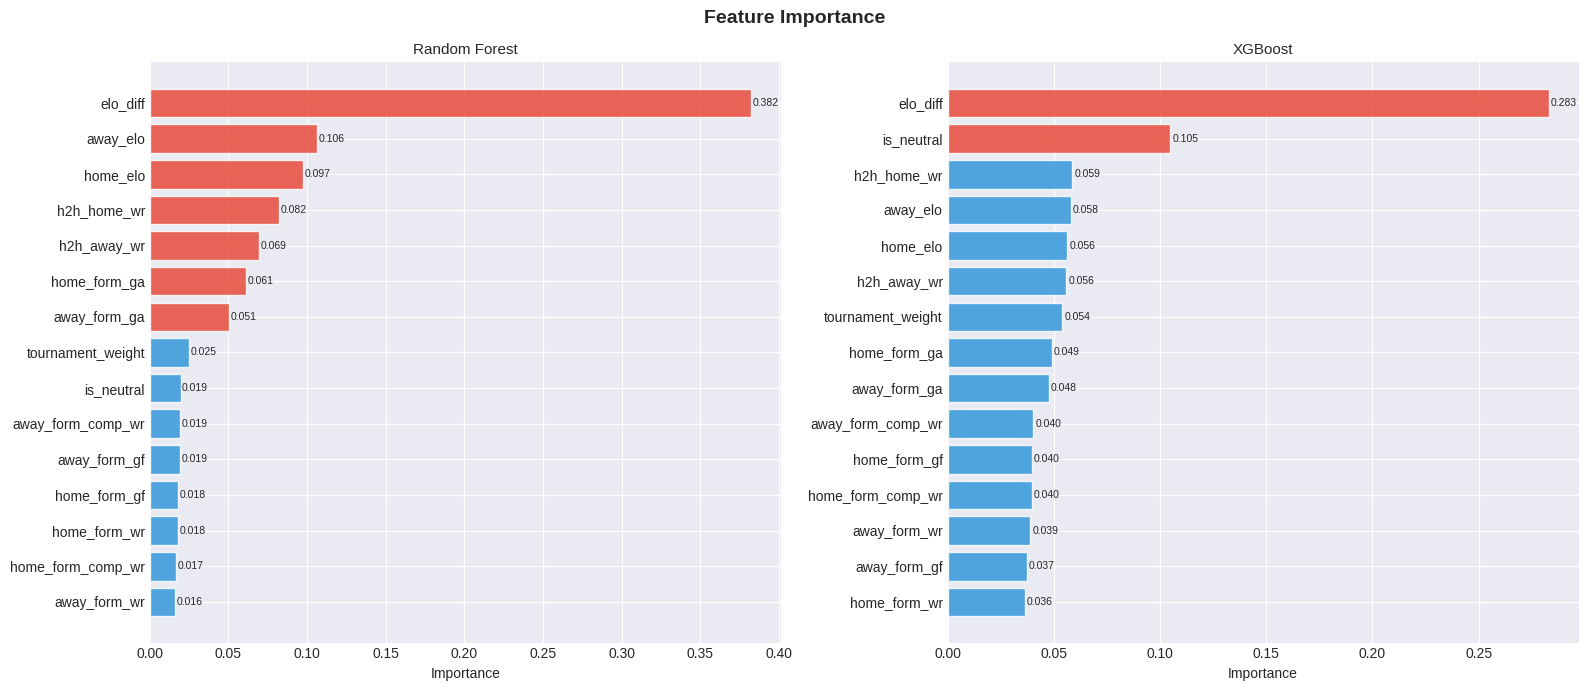

In [ ]:
# Native feature importance (tree-based models only)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance', fontsize=14, fontweight='bold')

for ax, model_name in zip(axes, ['Random Forest', 'XGBoost']):
    model = trained_models[model_name]

    if model_name == 'Random Forest':
        importances = model.feature_importances_
    else:
        importances = model.feature_importances_

    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)

    colors = ['#e74c3c' if v > feat_imp.median() * 1.5 else '#3498db'
              for v in feat_imp.values]
    ax.barh(feat_imp.index, feat_imp.values, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(f'{model_name}', fontsize=11)
    ax.set_xlabel('Importance')
    for bar, val in zip(ax.patches, feat_imp.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=7.5)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

Computing permutation importance for XGBoost...


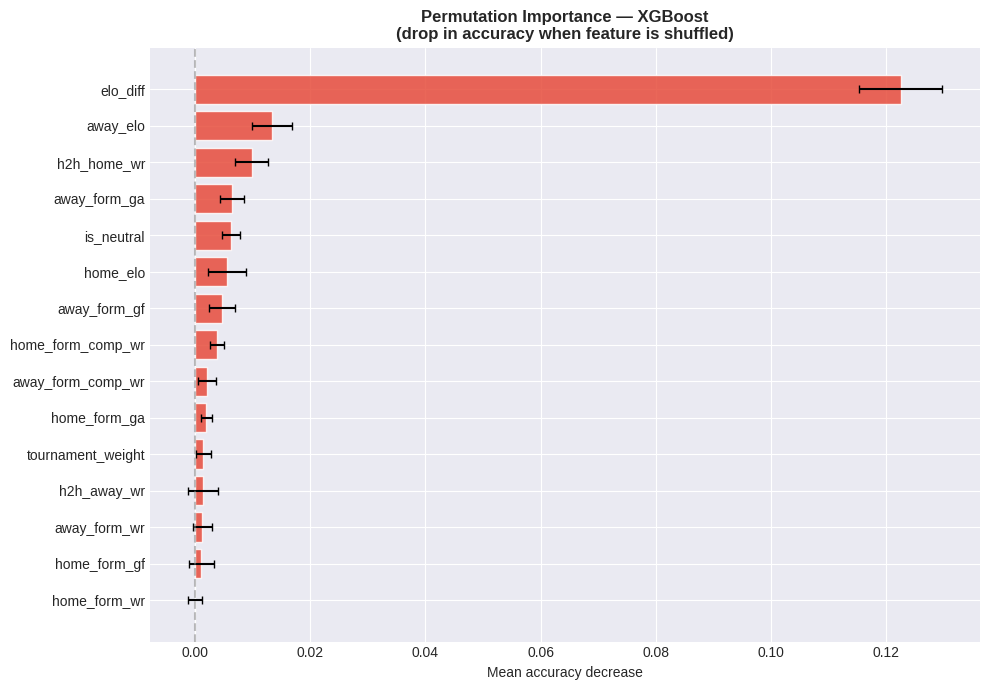


Top 5 most important features:
     feature  importance
    elo_diff    0.122545
    away_elo    0.013351
 h2h_home_wr    0.009857
away_form_ga    0.006421
  is_neutral    0.006290


In [ ]:
# Permutation importance on the best model
print(f'Computing permutation importance for {best_model_name}...')
perm_imp = permutation_importance(best_model, X_test, y_test,
                                   n_repeats=15, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': perm_imp.importances_mean,
    'std'       : perm_imp.importances_std,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in perm_df['importance']]
ax.barh(perm_df['feature'], perm_df['importance'],
        xerr=perm_df['std'], color=colors, alpha=0.85,
        edgecolor='white', capsize=3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title(f'Permutation Importance — {best_model_name}\n'
             f'(drop in accuracy when feature is shuffled)', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean accuracy decrease')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'permutation_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(perm_df.sort_values('importance', ascending=False).head(5)[['feature','importance']].to_string(index=False))

## 10. Probability Calibration Check

In tournament simulation, the model outputs **probabilities**, not just class predictions.

A well-calibrated model means: when it says a team has a 70% chance of winning, they win roughly 70% of the time.

This section checks calibration for the best model using a reliability diagram.

A good model follows the diagonal line closely.

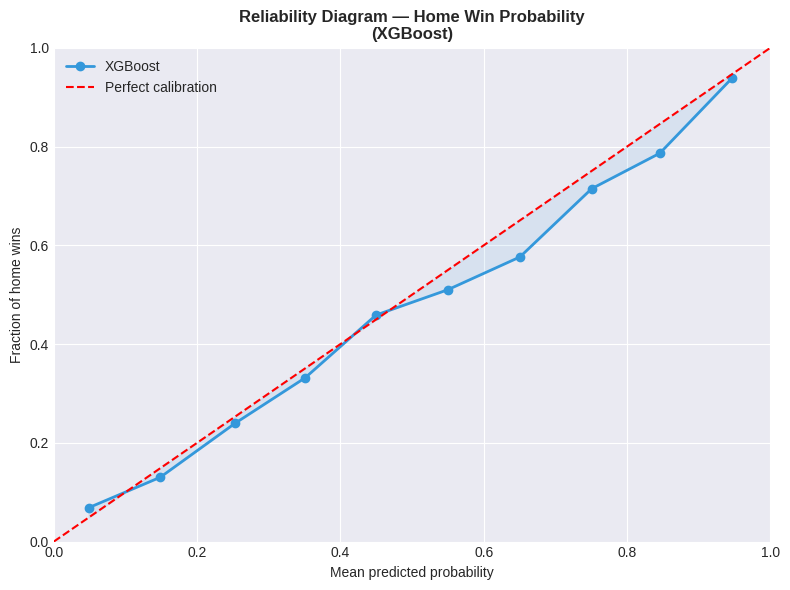

In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

best_model   = trained_models[best_model_name]
y_pred_proba = best_model.predict_proba(X_test)

# Check calibration for the 'Home Win' class (class index 2)
y_binary = (y_test == 2).astype(int)
prob_win  = y_pred_proba[:, 2]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_binary, prob_win, n_bins=10, strategy='uniform'
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mean_predicted_value, fraction_of_positives,
        marker='o', color='#3498db', linewidth=2, label=f'{best_model_name}')
ax.plot([0, 1], [0, 1], 'r--', label='Perfect calibration')
ax.fill_between(mean_predicted_value,
                fraction_of_positives, mean_predicted_value,
                alpha=0.1, color='#3498db')
ax.set_title('Reliability Diagram — Home Win Probability\n'
             f'({best_model_name})', fontsize=12, fontweight='bold')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of home wins')
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'calibration_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Match Prediction Function

A single function that takes two team names and returns win/draw/loss probabilities using the best trained model.

This function is used directly in Phase 4 for tournament simulation.

In [ ]:
def predict_match(home_team: str, away_team: str,
                  model,
                  final_elo_ratings: dict,
                  team_timeline: dict,
                  snapshot_date,
                  is_neutral: bool = True,
                  tournament_weight: float = 1.0) -> dict:
    """
    Predicts the outcome probabilities of a single match.

    Returns a dict with:
      home_win, draw, away_win   — probabilities (sum to 1.0)
      predicted_result           — most likely outcome (W / D / L)
    """

    home_elo = final_elo_ratings.get(home_team, 1500)
    away_elo = final_elo_ratings.get(away_team, 1500)

    home_form = get_form(home_team, snapshot_date)
    away_form = get_form(away_team, snapshot_date)
    h2h       = get_h2h(home_team, away_team, snapshot_date)

    features = pd.DataFrame([{
        'home_elo'          : home_elo,
        'away_elo'          : away_elo,
        'elo_diff'          : home_elo - away_elo,
        'home_form_wr'      : home_form['form_wr'],
        'away_form_wr'      : away_form['form_wr'],
        'home_form_gf'      : home_form['form_gf'],
        'home_form_ga'      : home_form['form_ga'],
        'away_form_gf'      : away_form['form_gf'],
        'away_form_ga'      : away_form['form_ga'],
        'home_form_comp_wr' : home_form['form_comp_wr'],
        'away_form_comp_wr' : away_form['form_comp_wr'],
        'h2h_home_wr'       : h2h['h2h_a_wr'],
        'h2h_away_wr'       : h2h['h2h_b_wr'],
        'is_neutral'        : int(is_neutral),
        'tournament_weight' : tournament_weight,
    }])

    probs = model.predict_proba(features[FEATURE_COLS])[0]
    # class order: 0=Away Win, 1=Draw, 2=Home Win
    away_win_p, draw_p, home_win_p = probs[0], probs[1], probs[2]

    result_idx = np.argmax(probs)
    result_map = {0: 'L', 1: 'D', 2: 'W'}

    return {
        'home_team'       : home_team,
        'away_team'       : away_team,
        'home_win'        : round(float(home_win_p), 3),
        'draw'            : round(float(draw_p),     3),
        'away_win'        : round(float(away_win_p), 3),
        'predicted_result': result_map[result_idx],
    }

print('predict_match() defined.')
print('\nTest prediction — Argentina vs Brazil (neutral, WC):')
test_pred = predict_match(
    home_team='Argentina', away_team='Brazil',
    model=best_model,
    final_elo_ratings=final_elo_ratings,
    team_timeline=ck['team_timeline'],
    snapshot_date=ck['SNAPSHOT_DATE'],
)
for k, v in test_pred.items():
    print(f'  {k:<20}: {v}')

predict_match() defined.

Test prediction — Argentina vs Brazil (neutral, WC):
  home_team           : Argentina
  away_team           : Brazil
  home_win            : 0.383
  draw                : 0.312
  away_win            : 0.306
  predicted_result    : W


## 12. Validation on the 2022 World Cup

As a final sanity check, the model is evaluated specifically on the **2022 FIFA World Cup** matches.

This is a realistic test because:
- The 2022 WC is in the test set (after the split date)
- It is an elite tournament where upsets still happen
- It gives context to the accuracy numbers

In [ ]:
wc2022_mask = (
    training_data['date'] >= SPLIT_DATE
) & (
    training_data['tournament'] == 'FIFA World Cup'
)

wc2022_data = training_data[wc2022_mask].copy()
X_wc2022    = wc2022_data[FEATURE_COLS]
y_wc2022    = wc2022_data[TARGET_COL]

y_pred_wc   = best_model.predict(X_wc2022)
y_prob_wc   = best_model.predict_proba(X_wc2022)

acc_wc   = accuracy_score(y_wc2022, y_pred_wc)
ll_wc    = log_loss(y_wc2022, y_prob_wc)

print(f'2022 World Cup — {best_model_name}')
print(f'  Matches evaluated : {len(wc2022_data)}')
print(f'  Accuracy          : {acc_wc:.3f}')
print(f'  Log-Loss          : {ll_wc:.3f}')
print()
print(classification_report(y_wc2022, y_pred_wc,
                             target_names=['Away Win', 'Draw', 'Home Win']))

# Show individual predictions for group stage
print('\nSample predictions on 2022 WC group stage:')
wc_display = wc2022_data.copy()
wc_display['predicted'] = y_pred_wc
wc_display['predicted_label'] = wc_display['predicted'].map(LABEL_MAP)
wc_display['actual_label']    = wc_display['result_num'].map(LABEL_MAP)
wc_display['correct']         = wc_display['predicted'] == wc_display['result_num']

cols = ['date','home_team','away_team','home_score','away_score',
        'actual_label','predicted_label','correct']
display(wc_display[cols].head(20))

correct_pct = wc_display['correct'].mean() * 100
print(f'\nCorrectly predicted: {wc_display["correct"].sum()} / {len(wc_display)}  ({correct_pct:.1f}%)')

2022 World Cup — XGBoost
  Matches evaluated : 136
  Accuracy          : 0.412
  Log-Loss          : 1.353

              precision    recall  f1-score   support

    Away Win       0.72      0.35      0.47        93
        Draw       0.25      0.07      0.11        15
    Home Win       0.26      0.79      0.39        28

    accuracy                           0.41       136
   macro avg       0.41      0.40      0.32       136
weighted avg       0.57      0.41      0.42       136


Sample predictions on 2022 WC group stage:


,date,home_team,away_team,home_score,away_score,actual_label,predicted_label,correct
25240,2022-11-20,Qatar,Ecuador,0.0,2.0,Away Win,Home Win,False
25258,2022-11-21,Senegal,Netherlands,0.0,2.0,Away Win,Away Win,True
25259,2022-11-21,England,Iran,6.0,2.0,Home Win,Home Win,True
25260,2022-11-21,United States,Wales,1.0,1.0,Draw,Home Win,False
25261,2022-11-22,France,Australia,4.0,1.0,Home Win,Home Win,True
25262,2022-11-22,Denmark,Tunisia,0.0,0.0,Draw,Home Win,False
25263,2022-11-22,Argentina,Saudi Arabia,1.0,2.0,Away Win,Home Win,False
25264,2022-11-22,Mexico,Poland,0.0,0.0,Draw,Away Win,False
25265,2022-11-23,Germany,Japan,1.0,2.0,Away Win,Home Win,False
25266,2022-11-23,Spain,Costa Rica,7.0,0.0,Home Win,Home Win,True



Correctly predicted: 56 / 136  (41.2%)


In [ ]:
models_dir = os.path.join(DRIVE_BASE, 'models')
os.makedirs(models_dir, exist_ok=True)

# Save all trained models
for name, model in trained_models.items():
    fname = name.lower().replace(' ', '_') + '.joblib'
    joblib.dump(model, os.path.join(models_dir, fname))
    print(f'Saved: {fname}')

# Save the phase 3 checkpoint
checkpoint3 = {
    **{k: v for k, v in ck.items()},
    'trained_models'  : trained_models,
    'best_model_name' : best_model_name,
    'best_model'      : best_model,
    'FEATURE_COLS'    : FEATURE_COLS,
    'LABEL_MAP'       : LABEL_MAP,
    'results_df'      : results_df,
    'SPLIT_DATE'      : SPLIT_DATE,
}

with open(os.path.join(DRIVE_BASE, 'phase3_checkpoint.pkl'), 'wb') as f:
    pickle.dump(checkpoint3, f)

print(f'\n Phase 3 checkpoint saved.')
print(f'Best model: {best_model_name}')

Saved: logistic_regression.joblib
Saved: random_forest.joblib
Saved: xgboost.joblib
Saved: lightgbm.joblib

 Phase 3 checkpoint saved.
Best model: XGBoost


# Phase 4 — Tournament Simulation


| Stage | Teams | Method |
|-------|-------|--------|
| Group Stage | 48 → 32 | Round per group |
| Round of 32 | 32 → 16 | Single elimination |
| Round of 16 | 16 → 8 | Single elimination |
| Quarterfinals | 8 → 4 | Single elimination |
| Semifinals | 4 → 2 | Single elimination |
| Final | 2 → 1 | Single elimination |

**Monte Carlo:** 10,000 full tournament simulations to produce championship probabilities.

## 1. Load Phase 3 Checkpoint

In [ ]:
DRIVE_BASE = '/content/drive/MyDrive/ML/wc2026'

with open(os.path.join(DRIVE_BASE, 'phase3_checkpoint.pkl'), 'rb') as f:
    ck = pickle.load(f)

best_model          = ck['best_model']
best_model_name     = ck['best_model_name']
FEATURE_COLS        = ck['FEATURE_COLS']
final_elo_ratings   = ck['final_elo_ratings']
team_timeline       = ck['team_timeline']
WC_2026_GROUPS_NORM = ck['WC_2026_GROUPS_NORM']
WC_2026_TEAMS_NORM  = ck['WC_2026_TEAMS_NORM']
wc_snapshot_df      = ck['wc_snapshot_df']
SNAPSHOT_DATE       = ck['SNAPSHOT_DATE']
FORM_WINDOW         = ck['FORM_WINDOW']
H2H_WINDOW          = ck['H2H_WINDOW']
results             = ck['results']

print(f'Best model loaded: {best_model_name}')
print(f'Tournament snapshot date: {SNAPSHOT_DATE.date()}')
print(f'Groups: {len(WC_2026_GROUPS_NORM)} | Teams: {len(WC_2026_TEAMS_NORM)}')

Best model loaded: XGBoost
Tournament snapshot date: 2026-06-10
Groups: 12 | Teams: 48


## 2. Helper Functions

The form and head-to-head functions from Phase 2 are redefined here so this notebook is self-contained.

In [ ]:
def get_form(team, before_date, window=None):
    """Win rate, goals for/against in the last N matches before a date."""
    if window is None:
        window = FORM_WINDOW
    default = {'form_wr': 0.5, 'form_gf': 1.2, 'form_ga': 1.2,
               'form_comp_wr': 0.5, 'form_n': 0}
    if team not in team_timeline:
        return default
    past = team_timeline[team]
    past = past[past['date'] < before_date]
    comp = past[~past['is_friendly']].tail(window)
    past = past.tail(window)
    if len(past) == 0:
        return default
    n    = len(past)
    wins = (past['result'] == 'W').sum()
    comp_wr = (comp['result'] == 'W').sum() / len(comp) if len(comp) > 0 else 0.5
    return {
        'form_wr'     : float(wins / n),
        'form_gf'     : float(past['gf'].mean()),
        'form_ga'     : float(past['ga'].mean()),
        'form_comp_wr': float(comp_wr),
        'form_n'      : int(n),
    }

def get_h2h(team_a, team_b, before_date, window=None):
    """Head-to-head win rate between two teams before a date."""
    if window is None:
        window = H2H_WINDOW
    default = {'h2h_a_wr': 0.5, 'h2h_b_wr': 0.5, 'h2h_n': 0}
    mask = (
        ((results['home_team'] == team_a) & (results['away_team'] == team_b)) |
        ((results['home_team'] == team_b) & (results['away_team'] == team_a))
    ) & (results['date'] < before_date)
    h2h = results[mask].sort_values('date').tail(window)
    if len(h2h) < 3:
        return default
    weights = np.linspace(0.5, 1.0, len(h2h))
    a_wins = b_wins = 0.0
    for w, (_, row) in zip(weights, h2h.iterrows()):
        if row['home_team'] == team_a:
            if row['result'] == 'W':   a_wins += w
            elif row['result'] == 'L': b_wins += w
        else:
            if row['result'] == 'L':   a_wins += w
            elif row['result'] == 'W': b_wins += w
    total = a_wins + b_wins + weights.sum() * 0.1
    return {'h2h_a_wr': float(a_wins/total), 'h2h_b_wr': float(b_wins/total), 'h2h_n': len(h2h)}

print('Helper functions defined.')

Helper functions defined.


In [ ]:
def predict_match(home_team, away_team, is_neutral=True, tournament_weight=1.0):
    """
    Returns win/draw/loss probabilities for a match.
    Uses the best model from Phase 3 and the pre-tournament snapshot.
    """
    home_elo = final_elo_ratings.get(home_team, 1500)
    away_elo = final_elo_ratings.get(away_team, 1500)
    hf = get_form(home_team, SNAPSHOT_DATE)
    af = get_form(away_team, SNAPSHOT_DATE)
    h2h = get_h2h(home_team, away_team, SNAPSHOT_DATE)

    X = pd.DataFrame([{
        'home_elo'          : home_elo,
        'away_elo'          : away_elo,
        'elo_diff'          : home_elo - away_elo,
        'home_form_wr'      : hf['form_wr'],
        'away_form_wr'      : af['form_wr'],
        'home_form_gf'      : hf['form_gf'],
        'home_form_ga'      : hf['form_ga'],
        'away_form_gf'      : af['form_gf'],
        'away_form_ga'      : af['form_ga'],
        'home_form_comp_wr' : hf['form_comp_wr'],
        'away_form_comp_wr' : af['form_comp_wr'],
        'h2h_home_wr'       : h2h['h2h_a_wr'],
        'h2h_away_wr'       : h2h['h2h_b_wr'],
        'is_neutral'        : int(is_neutral),
        'tournament_weight' : tournament_weight,
    }])

    probs = best_model.predict_proba(X[FEATURE_COLS])[0]
    # class order from training: 0=Away Win, 1=Draw, 2=Home Win
    return {
        'home_win': float(probs[2]),
        'draw'    : float(probs[1]),
        'away_win': float(probs[0]),
    }

# Quick check
p = predict_match('Argentina', 'France')
print(f'Argentina vs France:  Home Win {p["home_win"]:.1%}  |  Draw {p["draw"]:.1%}  |  Away Win {p["away_win"]:.1%}')
p = predict_match('Mexico', 'South Africa')
print(f'Mexico vs South Africa: Home Win {p["home_win"]:.1%}  |  Draw {p["draw"]:.1%}  |  Away Win {p["away_win"]:.1%}')

Argentina vs France:  Home Win 38.7%  |  Draw 23.6%  |  Away Win 37.7%
Mexico vs South Africa: Home Win 46.3%  |  Draw 36.1%  |  Away Win 17.6%


## 3. Group Stage Simulation

Each group plays a round-robin — every team plays once against each other team in the group.

#### Points system

| Result | Points |
|--------|--------|
| Win | 3 |
| Draw | 1 |
| Loss | 0 |

#### Tiebreaker order (FIFA 2026 rules)

1. Points
2. Goal difference
3. Goals scored
4. Head-to-head points
5. Head-to-head goal difference

#### Stochastic sampling

In the deterministic simulation, the most likely result is used.
In the Monte Carlo simulation, results are **sampled** from the probability distribution to capture uncertainty.

In [ ]:
def simulate_match(home_team, away_team, stochastic=False):
    """Returns outcome W/D/L and probs [home_win, draw, away_win]."""
    probs = prob_cache[(home_team, away_team)]   # instant dict lookup

    if stochastic:
        outcome = np.random.choice(['W', 'D', 'L'], p=probs)
    else:
        outcome = ['W', 'D', 'L'][int(np.argmax(probs))]

    return outcome, probs

def simulate_group(teams, stochastic=False):
    """
    Simulates a full group round-robin.
    Returns a DataFrame with standings sorted by points, GD, GF.
    """
    teams = [f'{t}' for t in teams]

    # Initialize stats
    stats = {t: {'team': t, 'MP': 0, 'W': 0, 'D': 0, 'L': 0,
                 'GF': 0, 'GA': 0, 'GD': 0, 'Pts': 0} for t in teams}

    # Simulate all matchups
    for home, away in combinations(teams, 2):
        result, probs = simulate_match(home, away, stochastic=stochastic)

        # Simulate goal counts (simple Poisson based on form)
        h_form = team_forms[home]
        a_form = team_forms[away]
        avg_gf = (h_form['form_gf'] + a_form['form_ga']) / 2
        avg_ga = (a_form['form_gf'] + h_form['form_ga']) / 2

        if stochastic:
            hg = int(np.random.poisson(max(0.3, avg_gf)))
            ag = int(np.random.poisson(max(0.3, avg_ga)))
            # Align goal counts with the sampled result
            if result == 'W' and hg <= ag:
                hg, ag = ag + 1, max(0, hg - 1)
            elif result == 'L' and hg >= ag:
                hg, ag = max(0, ag - 1), hg + 1
            elif result == 'D':
                ag = hg
        else:
            hg = round(avg_gf)
            ag = round(avg_ga)
            if result == 'W' and hg <= ag: hg, ag = ag+1, hg
            elif result == 'L' and hg >= ag: hg, ag = ag, hg+1
            elif result == 'D': ag = hg

        # Update stats
        for team, gf, ga, res in [(home, hg, ag, result), (away, ag, hg, {'W':'L','L':'W','D':'D'}[result])]:
            stats[team]['MP'] += 1
            stats[team]['GF'] += gf
            stats[team]['GA'] += ga
            stats[team]['GD'] += gf - ga
            if res == 'W':
                stats[team]['W']   += 1
                stats[team]['Pts'] += 3
            elif res == 'D':
                stats[team]['D']   += 1
                stats[team]['Pts'] += 1
            else:
                stats[team]['L']   += 1

    standings = pd.DataFrame(list(stats.values()))
    standings = standings.sort_values(['Pts','GD','GF'], ascending=False).reset_index(drop=True)
    standings['Pos'] = standings.index + 1
    return standings

print('simulate_group() and simulate_match() defined.')

simulate_group() and simulate_match() defined.


In [ ]:
# ── Precompute all match probabilities in a single batch call ────────────────
from itertools import permutations

print('Precomputing probabilities for all team pairs...')

teams        = WC_2026_TEAMS_NORM
all_pairs    = list(permutations(teams, 2))   # 48×47 = 2,256 ordered pairs

team_forms = {team: get_form(team, SNAPSHOT_DATE) for team in teams}
print(f'  Form stats cached for {len(team_forms)} teams.')

# Build one big feature matrix for all pairs
batch_rows = []
for home, away in all_pairs:
    home_elo = final_elo_ratings.get(home, 1500)
    away_elo = final_elo_ratings.get(away, 1500)
    hf  = team_forms[home]
    af  = team_forms[away]
    h2h = get_h2h(home, away, SNAPSHOT_DATE)

    batch_rows.append({
        'home_elo'          : home_elo,
        'away_elo'          : away_elo,
        'elo_diff'          : home_elo - away_elo,
        'home_form_wr'      : hf['form_wr'],
        'away_form_wr'      : af['form_wr'],
        'home_form_gf'      : hf['form_gf'],
        'home_form_ga'      : hf['form_ga'],
        'away_form_gf'      : af['form_gf'],
        'away_form_ga'      : af['form_ga'],
        'home_form_comp_wr' : hf['form_comp_wr'],
        'away_form_comp_wr' : af['form_comp_wr'],
        'h2h_home_wr'       : h2h['h2h_a_wr'],
        'h2h_away_wr'       : h2h['h2h_b_wr'],
        'is_neutral'        : 1,
        'tournament_weight' : 1.0,
    })

X_batch    = pd.DataFrame(batch_rows)[FEATURE_COLS]
all_probs  = best_model.predict_proba(X_batch)   # shape: (2256, 3)

# Store as {(home, away): np.array([home_win, draw, away_win])}
# Model class order: 0=Away Win, 1=Draw, 2=Home Win → reorder to [HW, D, AW]
prob_cache = {}
for (home, away), p in zip(all_pairs, all_probs):
    arr = np.array([p[2], p[1], p[0]], dtype=np.float64)
    arr /= arr.sum()   # normalize — eliminates the float precision error
    prob_cache[(home, away)] = arr

print(f'  Probabilities cached for {len(prob_cache)} matchups.')

Precomputing probabilities for all team pairs...
  Form stats cached for 48 teams.
  Probabilities cached for 2256 matchups.


## 4. Single Tournament Simulation (Deterministic)

A full deterministic simulation of the tournament using the most likely outcome for each match.

This gives the most probable bracket path — not necessarily the winner, since single-elimination is highly sensitive to small probability differences.

In [ ]:
def simulate_all_groups(stochastic=True):
    """Simulates all 12 groups and returns standings + team-to-group mapping."""
    all_standings = {}
    for grp, teams in WC_2026_GROUPS_NORM.items():
        all_standings[grp] = simulate_group(teams, stochastic=stochastic)
    return all_standings

def get_advancing_teams(all_standings):
    winners    = []
    runners_up = []
    thirds     = []

    for grp, standings in all_standings.items():
        winners.append({
            'team': f"{standings.iloc[0]['team']}", 'group': grp,
            'pts': standings.iloc[0]['Pts'], 'gd': standings.iloc[0]['GD'],
            'gf': standings.iloc[0]['GF']})
        runners_up.append({
            'team': f"{standings.iloc[1]['team']}", 'group': grp,
            'pts': standings.iloc[1]['Pts'], 'gd': standings.iloc[1]['GD'],
            'gf': standings.iloc[1]['GF']})
        thirds.append({
            'team': f"{standings.iloc[2]['team']}", 'group': grp,
            'pts': standings.iloc[2]['Pts'], 'gd': standings.iloc[2]['GD'],
            'gf': standings.iloc[2]['GF']})

    thirds_df     = pd.DataFrame(thirds).sort_values(['pts','gd','gf'], ascending=False)
    best_8_thirds = thirds_df.head(8).to_dict('records')
    return winners, runners_up, best_8_thirds


def build_r32_bracket(winners, runners_up, best_8_thirds):
    """
    Builds 16 Round of 32 matchups.
    Each of the 32 advancing teams appears EXACTLY ONCE.

    Structure (simplified FIFA seeding logic):
      - 8 matchups: group winner vs best third-place team
      - 8 matchups: group runner-up vs group runner-up (cross-group)
    """
    w  = [x['team'] for x in winners]      # 12 group winners
    r  = [x['team'] for x in runners_up]   # 12 runners-up
    t3 = [x['team'] for x in best_8_thirds] # 8 best thirds

    # 8 winners face the 8 best thirds (seeds 1-8 vs seeds 25-32)
    matchups = [(w[i], t3[i]) for i in range(8)]

    # Remaining 4 winners face runners-up from cross-groups
    # w[8]  vs r[9], w[9]  vs r[8]
    # w[10] vs r[11], w[11] vs r[10]
    matchups += [
        (w[8],  r[9]),
        (w[9],  r[8]),
        (w[10], r[11]),
        (w[11], r[10]),
    ]

    # Remaining 8 runners-up face each other (cross-group pairs)
    # r[0] vs r[1], r[2] vs r[3], r[4] vs r[5], r[6] vs r[7]
    matchups += [
        (r[0], r[1]),
        (r[2], r[3]),
        (r[4], r[5]),
        (r[6], r[7]),
    ]

    # Validate: all 32 teams appear exactly once
    all_teams = [t for pair in matchups for t in pair]
    if len(all_teams) != 32 or len(set(all_teams)) != 32:
        dupes = [t for t in all_teams if all_teams.count(t) > 1]
        print(f' Bracket issue: {len(all_teams)} teams, dupes: {set(dupes)}')

    return matchups

def simulate_knockout_round(matchups, stochastic=False):
    """Simulates one knockout round. Returns list of winners."""
    next_round = []
    for home, away in matchups:
        result, probs = simulate_match(home, away, stochastic=stochastic)
        if result == 'W':
            next_round.append(home)
        elif result == 'L':
            next_round.append(away)
        else:
          hw = float(probs[0])
          aw = float(probs[2])
          total = hw + aw
          if total == 0:
              normalized = np.array([0.5, 0.5])
          else:
              normalized = np.array([hw / total, aw / total])
          normalized = normalized / normalized.sum()   # ← por si acaso
          winner = np.random.choice([home, away], p=normalized)
          next_round.append(winner)
    return next_round

def pair_for_next_round(teams):
    """Pairs teams sequentially for the next knockout round."""
    return [(teams[i], teams[i+1]) for i in range(0, len(teams), 2)]

print('Tournament simulation functions defined.')

Tournament simulation functions defined.


In [ ]:
print('Simulating tournament (deterministic)...')

# Group stage — stochastic with fixed seed for reproducibility
np.random.seed(42)
all_standings = simulate_all_groups(stochastic=True)

# Knockout stage — deterministic (most likely bracket path)
winners, runners_up, best_8_thirds = get_advancing_teams(all_standings)
r32_matchups = build_r32_bracket(winners, runners_up, best_8_thirds)
r16_teams    = simulate_knockout_round(r32_matchups,                      stochastic=False)
qf_teams     = simulate_knockout_round(pair_for_next_round(r16_teams),    stochastic=False)
sf_teams     = simulate_knockout_round(pair_for_next_round(qf_teams),     stochastic=False)
final_teams  = simulate_knockout_round(pair_for_next_round(sf_teams),     stochastic=False)
champion     = simulate_knockout_round([(final_teams[0], final_teams[1])],stochastic=False)

print('\n=== GROUP STAGE STANDINGS ===')
for grp, standings in all_standings.items():
    print(f'\nGroup {grp}:')
    display(standings[['Pos','team','MP','W','D','L','GF','GA','GD','Pts']])

winners, runners_up, best_8_thirds = get_advancing_teams(all_standings)

print(f'\n=== TEAMS ADVANCING ===')
print(f'Group Winners (12):   {[w["team"] for w in winners]}')
print(f'Runners-up (12):      {[r["team"] for r in runners_up]}')
print(f'Best 8 Thirds:        {[t["team"] for t in best_8_thirds]}')
print(f'Total advancing:      {12 + 12 + len(best_8_thirds)}')

Simulating tournament (deterministic)...

=== GROUP STAGE STANDINGS ===

Group A:


,Pos,team,MP,W,D,L,GF,GA,GD,Pts
0,1,Mexico,3,3,0,0,8,2,6,9
1,2,South Korea,3,0,2,1,4,5,-1,2
2,3,Czech Republic,3,0,2,1,2,4,-2,2
3,4,South Africa,3,0,2,1,2,5,-3,2



Group B:


,Pos,team,MP,W,D,L,GF,GA,GD,Pts
0,1,Canada,3,2,1,0,6,1,5,7
1,2,Qatar,3,1,2,0,4,2,2,5
2,3,Switzerland,3,1,0,2,1,4,-3,3
3,4,Bosnia and Herzegovina,3,0,1,2,1,5,-4,1



Group C:


...


Group K:


,Pos,team,MP,W,D,L,GF,GA,GD,Pts
0,1,Colombia,3,2,0,1,5,1,4,6
1,2,Portugal,3,2,0,1,4,3,1,6
2,3,Uzbekistan,3,1,1,1,2,3,-1,4
3,4,DR Congo,3,0,1,2,1,5,-4,1



Group L:


,Pos,team,MP,W,D,L,GF,GA,GD,Pts
0,1,Panama,3,2,1,0,9,4,5,7
1,2,Croatia,3,1,1,1,5,5,0,4
2,3,England,3,0,3,0,4,4,0,3
3,4,Ghana,3,0,1,2,3,8,-5,1



=== TEAMS ADVANCING ===
Group Winners (12):   ['Mexico', 'Canada', 'Morocco', 'United States', 'Germany', 'Netherlands', 'Belgium', 'Spain', 'Norway', 'Algeria', 'Colombia', 'Panama']
Runners-up (12):      ['South Korea', 'Qatar', 'Brazil', 'Australia', 'Ivory Coast', 'Japan', 'Egypt', 'Uruguay', 'France', 'Jordan', 'Portugal', 'Croatia']
Best 8 Thirds:        ['Uzbekistan', 'New Zealand', 'England', 'Ecuador', 'Scotland', 'Argentina', 'Switzerland', 'Paraguay']
Total advancing:      32


In [ ]:
def simulate_knockout_round(matchups, stochastic=False):
    """Simulates one knockout round. Returns list of winners."""
    next_round = []
    for home, away in matchups:
        result, probs = simulate_match(home, away, stochastic=stochastic) # probs is [P(Home), P(Draw), P(Away)]
        if result == 'W':
            next_round.append(home)
        elif result == 'L':
            next_round.append(away)
        else:
            # Draws in knockout → extra time → penalties (coin flip weighted by probs)
            # probs[0] is P(Home Win), probs[2] is P(Away Win). Their sum is not 1 because P(Draw) is present.
            # We need to normalize P(Home Win) and P(Away Win) to sum to 1 for the choice between home and away.
            home_win_prob_for_tiebreaker = probs[0] # P(Home Win)
            away_win_prob_for_tiebreaker = probs[2] # P(Away Win)

            sum_of_win_loss_probs = home_win_prob_for_tiebreaker + away_win_prob_for_tiebreaker

            if sum_of_win_loss_probs == 0: # Avoid division by zero if both are 0
                # If probabilities for win/loss are both zero, default to equal chance
                normalized_probs = [0.5, 0.5]
            else:
                normalized_probs = [
                    home_win_prob_for_tiebreaker / sum_of_win_loss_probs,
                    away_win_prob_for_tiebreaker / sum_of_win_loss_probs
                ]

            winner = np.random.choice([home, away], p=normalized_probs)
            next_round.append(winner)
    return next_round

# Knockout stage
r32_matchups = build_r32_bracket(winners, runners_up, best_8_thirds)

print('\n=== ROUND OF 32 ===')
for i, (h, a) in enumerate(r32_matchups, 1):
    p = predict_match(h, a)
    fav = h if p['home_win'] > p['away_win'] else a
    print(f'  Match {i:2d}: {h:<25} vs {a:<25} → Favorite: {fav}')

r16_teams = simulate_knockout_round(r32_matchups, stochastic=False)
print(f'\n=== ROUND OF 16 ({len(r16_teams)} teams) ===')
print(f'  {r16_teams}')

r16_matchups = pair_for_next_round(r16_teams)
qf_teams = simulate_knockout_round(r16_matchups, stochastic=False)
print(f'\n=== QUARTERFINALS ({len(qf_teams)} teams) ===')
print(f'  {qf_teams}')

qf_matchups = pair_for_next_round(qf_teams)
sf_teams = simulate_knockout_round(qf_matchups, stochastic=False)
print(f'\n=== SEMIFINALS ({len(sf_teams)} teams) ===')
print(f'  {sf_teams}')

sf_matchups = pair_for_next_round(sf_teams)
final_teams = simulate_knockout_round(sf_matchups, stochastic=False)
print(f'\n=== FINAL ===')
print(f'  {final_teams[0]} vs {final_teams[1]}')

champion = simulate_knockout_round([(final_teams[0], final_teams[1])], stochastic=False)
print(f'\n🏆 PREDICTED CHAMPION: {champion[0]}')



=== ROUND OF 32 ===
  Match  1: Mexico                    vs Uzbekistan                → Favorite: Uzbekistan
  Match  2: Canada                    vs New Zealand               → Favorite: Canada
  Match  3: Morocco                   vs England                   → Favorite: Morocco
  Match  4: United States             vs Ecuador                   → Favorite: Ecuador
  Match  5: Germany                   vs Scotland                  → Favorite: Germany
  Match  6: Netherlands               vs Argentina                 → Favorite: Netherlands
  Match  7: Belgium                   vs Switzerland               → Favorite: Switzerland
  Match  8: Spain                     vs Paraguay                  → Favorite: Spain
  Match  9: Norway                    vs Jordan                    → Favorite: Norway
  Match 10: Algeria                   vs France                    → Favorite: France
  Match 11: Colombia                  vs Croatia                   → Favorite: Colombia
  Match 12: Pan

## 5. Monte Carlo Simulation

A single deterministic prediction doesn't capture uncertainty.

**10,000 independent tournament simulations** are run, each with stochastic match results sampled from the model's probability distribution.

The frequency of each outcome across all simulations gives the probability:

```
P(team wins championship) = number of simulations where team won / 10,000
```

This approach propagates uncertainty through every stage of the tournament and produces realistic probability distributions.

In [ ]:
N_SIMULATIONS = 10000

# Counters
champion_count = {t: 0 for t in WC_2026_TEAMS_NORM}
final_count    = {t: 0 for t in WC_2026_TEAMS_NORM}
sf_count       = {t: 0 for t in WC_2026_TEAMS_NORM}
qf_count       = {t: 0 for t in WC_2026_TEAMS_NORM}
r16_count      = {t: 0 for t in WC_2026_TEAMS_NORM}
advance_count  = {t: 0 for t in WC_2026_TEAMS_NORM}

print(f'Running {N_SIMULATIONS:,} Monte Carlo simulations...')

for sim in tqdm(range(N_SIMULATIONS)):
    try:
        # Group stage
        gs = simulate_all_groups(stochastic=True)
        w, r, t3 = get_advancing_teams(gs)

        all_advancing = [x['team'] for x in w + r + t3]
        for t in all_advancing:
            advance_count[t] = advance_count.get(t, 0) + 1

        # Round of 32
        r32 = build_r32_bracket(w, r, t3)
        r16_t = simulate_knockout_round(r32, stochastic=True)
        for t in r16_t:
            r16_count[t] = r16_count.get(t, 0) + 1

        # Quarterfinals
        qf_t = simulate_knockout_round(pair_for_next_round(r16_t), stochastic=True)
        for t in qf_t:
            qf_count[t] = qf_count.get(t, 0) + 1

        # Semifinals
        sf_t = simulate_knockout_round(pair_for_next_round(qf_t), stochastic=True)
        for t in sf_t:
            sf_count[t] = sf_count.get(t, 0) + 1

        # Final
        fin_t = simulate_knockout_round(pair_for_next_round(sf_t), stochastic=True)
        for t in fin_t:
            final_count[t] = final_count.get(t, 0) + 1

        # Champion
        champ = simulate_knockout_round([(fin_t[0], fin_t[1])], stochastic=True)
        champion_count[champ[0]] = champion_count.get(champ[0], 0) + 1

    except Exception as e:
        if sim < 3:          # solo imprime los primeros 3 errores
            print(f'Error en sim {sim}: {type(e).__name__}: {e}')
        continue
print(f'\nSimulations complete.')

Running 10,000 Monte Carlo simulations...


  0%|          | 0/10000 [00:00<?, ?it/s]


Simulations complete.


## 6. Monte Carlo Results

In [ ]:
# Build results DataFrame
mc_results = pd.DataFrame({
    'team'       : list(WC_2026_TEAMS_NORM),
    'champion'   : [champion_count.get(t, 0) / N_SIMULATIONS for t in WC_2026_TEAMS_NORM],
    'final'      : [final_count.get(t, 0)    / N_SIMULATIONS for t in WC_2026_TEAMS_NORM],
    'semifinal'  : [sf_count.get(t, 0)       / N_SIMULATIONS for t in WC_2026_TEAMS_NORM],
    'quarterfinal': [qf_count.get(t, 0)      / N_SIMULATIONS for t in WC_2026_TEAMS_NORM],
    'round_of_16': [r16_count.get(t, 0)      / N_SIMULATIONS for t in WC_2026_TEAMS_NORM],
    'advance_gs' : [advance_count.get(t, 0)  / N_SIMULATIONS for t in WC_2026_TEAMS_NORM],
})

# Add group info
group_map = {t: grp for grp, teams in WC_2026_GROUPS_NORM.items() for t in teams}
mc_results['group'] = mc_results['team'].map(group_map)
mc_results = mc_results.sort_values('champion', ascending=False).reset_index(drop=True)

print('=== CHAMPIONSHIP PROBABILITIES — TOP 20 ===')
top20 = mc_results.head(20).copy()
for col in ['champion','final','semifinal','quarterfinal','round_of_16','advance_gs']:
    top20[col] = top20[col].apply(lambda x: f'{x:.1%}')
display(top20[['team','group','advance_gs','round_of_16','quarterfinal',
               'semifinal','final','champion']])

=== CHAMPIONSHIP PROBABILITIES — TOP 20 ===


,team,group,advance_gs,round_of_16,quarterfinal,semifinal,final,champion
0,Spain,H,96.8%,84.8%,71.9%,55.0%,41.1%,30.7%
1,Brazil,C,92.6%,69.7%,50.9%,34.0%,18.9%,10.6%
2,France,I,93.1%,65.5%,41.9%,30.5%,20.5%,10.0%
3,Argentina,J,95.4%,62.1%,33.2%,23.7%,15.3%,7.2%
4,Germany,E,96.1%,68.3%,45.8%,24.8%,12.8%,6.5%
5,Morocco,C,90.5%,66.1%,46.8%,28.6%,12.3%,5.4%
6,England,L,94.7%,63.0%,38.9%,18.3%,10.7%,4.2%
7,Turkey,D,80.9%,53.2%,29.6%,17.5%,7.7%,3.4%
8,Netherlands,F,90.6%,60.0%,32.0%,15.8%,6.8%,3.3%
9,Switzerland,B,95.9%,66.2%,40.6%,19.9%,7.3%,3.1%


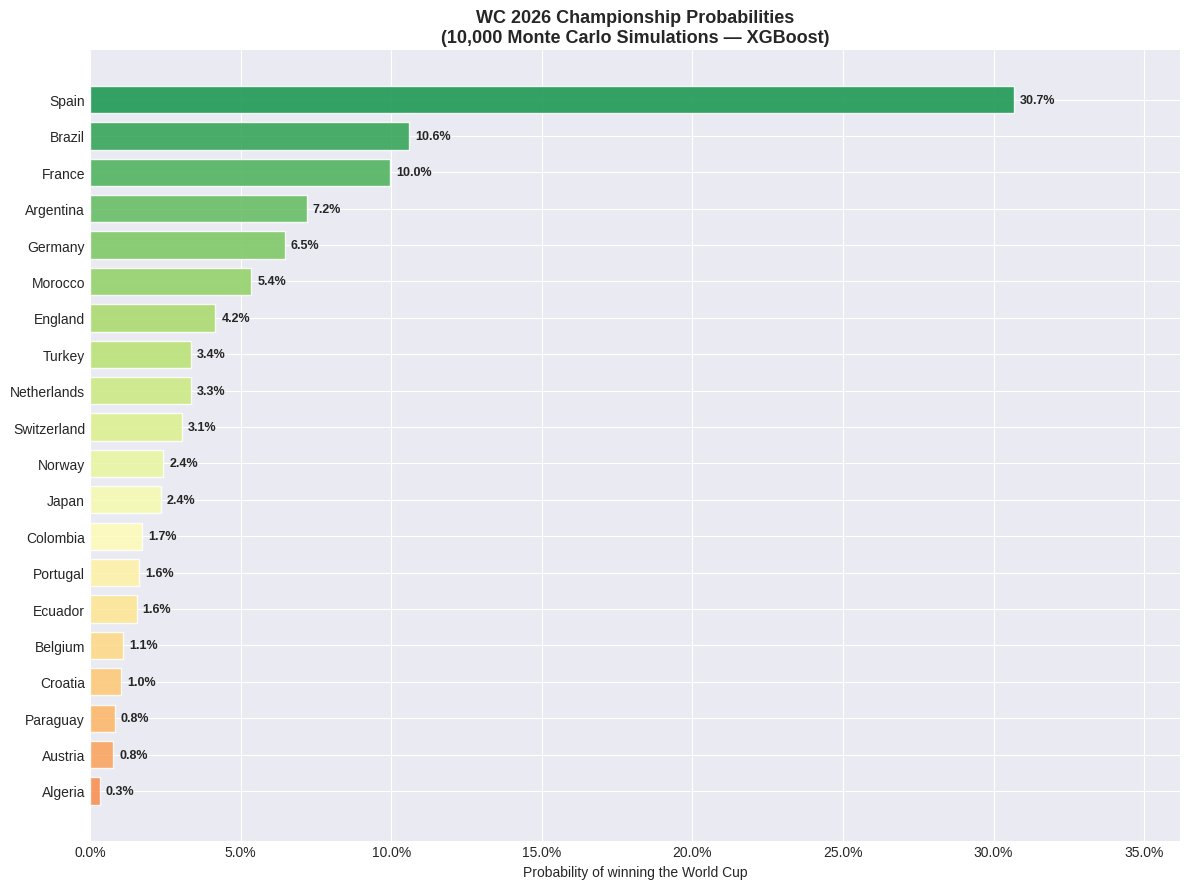

In [ ]:
# ── Championship probability bar chart ─────────────────────────────────────
top_n = mc_results.head(20).sort_values('champion', ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))

palette = plt.cm.RdYlGn(np.linspace(0.25, 0.9, len(top_n)))
bars = ax.barh(top_n['team'], top_n['champion'],
               color=palette, alpha=0.88, edgecolor='white', height=0.75)

for bar, val in zip(bars, top_n['champion']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', ha='left', fontsize=9, fontweight='bold')

ax.set_title(
    f'WC 2026 Championship Probabilities\n({N_SIMULATIONS:,} Monte Carlo Simulations — {best_model_name})',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Probability of winning the World Cup')
ax.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_xlim(0, top_n['champion'].max() * 1.18)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'championship_probabilities.png'), dpi=150, bbox_inches='tight')
plt.show()

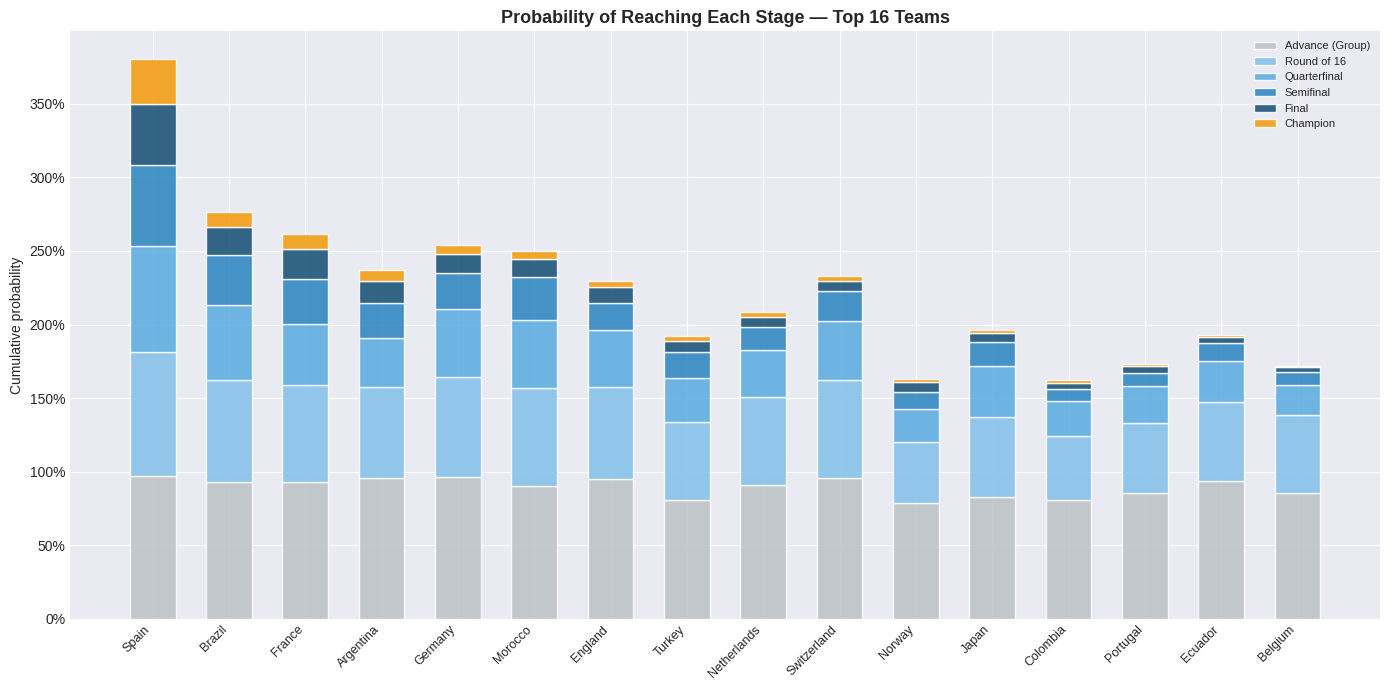

In [ ]:
# ── Stacked bar: probability of reaching each round ─────────────────────────
top16 = mc_results.head(16).sort_values('champion', ascending=False)

stages = ['advance_gs', 'round_of_16', 'quarterfinal', 'semifinal', 'final', 'champion']
stage_labels = ['Advance (Group)', 'Round of 16', 'Quarterfinal', 'Semifinal', 'Final', 'Champion']
colors_stages = ['#bdc3c7', '#85c1e9', '#5dade2', '#2e86c1', '#1a5276', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(top16))
width = 0.6
bottom = np.zeros(len(top16))

for stage, label, color in zip(stages, stage_labels, colors_stages):
    vals = top16[stage].values
    ax.bar(x, vals, width, bottom=bottom, label=label, color=color, alpha=0.88, edgecolor='white')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(top16['team'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Cumulative probability')
ax.set_title('Probability of Reaching Each Stage — Top 16 Teams', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'stage_probabilities.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Group Stage Predictions

Deterministic group standings and the most likely match results for all 48 group stage matches.

In [ ]:
print('=== DETERMINISTIC GROUP STAGE PREDICTIONS ===\n')

all_st = simulate_all_groups(stochastic=True)

for grp, standings in all_st.items():
    print(f'Group {grp}:')
    print(f'  {"Pos":<4} {"Team":<28} {"MP":>3} {"W":>3} {"D":>3} {"L":>3} {"GF":>4} {"GA":>4} {"GD":>4} {"Pts":>4}')
    for _, row in standings.iterrows():
        marker = ' ✅' if row['Pos'] <= 2 else ' (3rd)' if row['Pos'] == 3 else ''
        print(f'  {int(row["Pos"]):<4} {row["team"]:<28} {int(row["MP"]):>3} {int(row["W"]):>3} '
              f'{int(row["D"]):>3} {int(row["L"]):>3} {int(row["GF"]):>4} '
              f'{int(row["GA"]):>4} {int(row["GD"]):>4} {int(row["Pts"]):>4}{marker}')
    print()

=== DETERMINISTIC GROUP STAGE PREDICTIONS ===

Group A:
  Pos  Team                          MP   W   D   L   GF   GA   GD  Pts
  1    Mexico                         3   2   1   0    5    2    3    7 ✅
  2    South Korea                    3   1   1   1    2    1    1    4 ✅
  3    Czech Republic                 3   1   0   2    7    7    0    3 (3rd)
  4    South Africa                   3   1   0   2    3    7   -4    3

Group B:
  Pos  Team                          MP   W   D   L   GF   GA   GD  Pts
  1    Switzerland                    3   3   0   0    5    0    5    9 ✅
  2    Canada                         3   1   1   1    5    5    0    4 ✅
  3    Qatar                          3   1   0   2    3    3    0    3 (3rd)
  4    Bosnia and Herzegovina         3   0   1   2    4    9   -5    1

Group C:
  Pos  Team                          MP   W   D   L   GF   GA   GD  Pts
  1    Brazil                         3   3   0   0    6    0    6    9 ✅
  2    Morocco                        

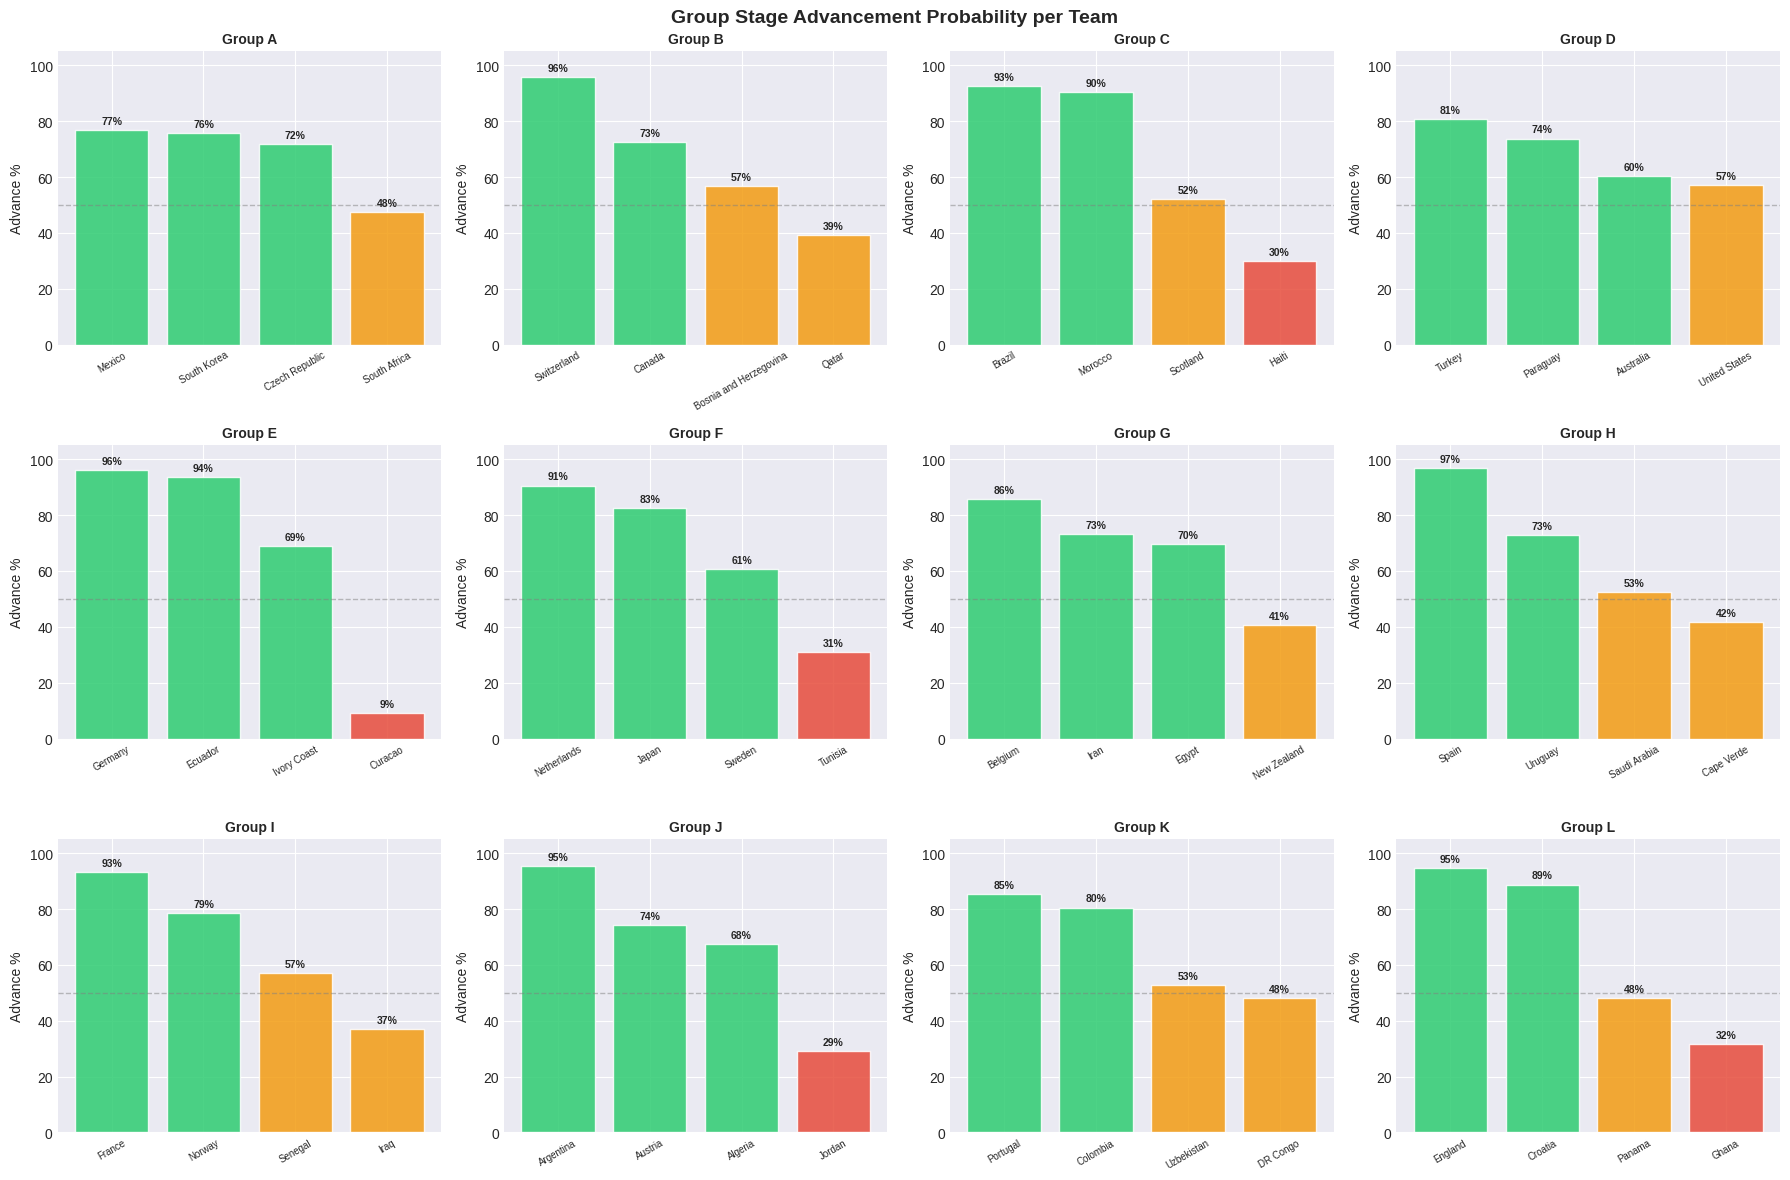

In [ ]:
# ── Group stage advance probability heatmap ─────────────────────────────────
advance_by_group = []
for grp, teams in WC_2026_GROUPS_NORM.items():
    for team in teams:
        advance_by_group.append({
            'group': grp,
            'team' : team,
            'advance_pct': advance_count.get(team, 0) / N_SIMULATIONS * 100,
            'r16_pct'    : r16_count.get(team, 0)    / N_SIMULATIONS * 100,
        })

adv_df = pd.DataFrame(advance_by_group)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Group Stage Advancement Probability per Team', fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, (grp, gdf) in zip(axes, adv_df.groupby('group')):
    gdf = gdf.sort_values('advance_pct', ascending=False)
    colors = ['#2ecc71' if p > 60 else '#f39c12' if p > 35 else '#e74c3c'
              for p in gdf['advance_pct']]
    bars = ax.bar(gdf['team'], gdf['advance_pct'], color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(f'Group {grp}', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 105)
    ax.set_ylabel('Advance %')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    for bar, val in zip(bars, gdf['advance_pct']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                f'{val:.0f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'group_advance_probs.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Key Matchup Analysis

Head-to-head probabilities for the most anticipated matches of the tournament.

=== KEY MATCHUP PROBABILITIES ===

  Home                 Away                   Home Win     Draw   Away Win Favorite
  ---------------------------------------------------------------------------
  Argentina            France                   38.7%   23.6%     37.7%   Argentina
  Spain                England                  56.2%   27.0%     16.8%   Spain
  Brazil               Germany                  49.5%   24.7%     25.8%   Brazil
  Argentina            Brazil                   43.1%   30.0%     26.9%   Argentina
  France               Portugal                 62.1%   20.6%     17.3%   France
  Spain                France                   54.6%   20.2%     25.1%   Spain
  Mexico               United States            36.0%   36.3%     27.7%   Mexico
  Argentina            Spain                    19.3%   45.5%     35.2%   Spain


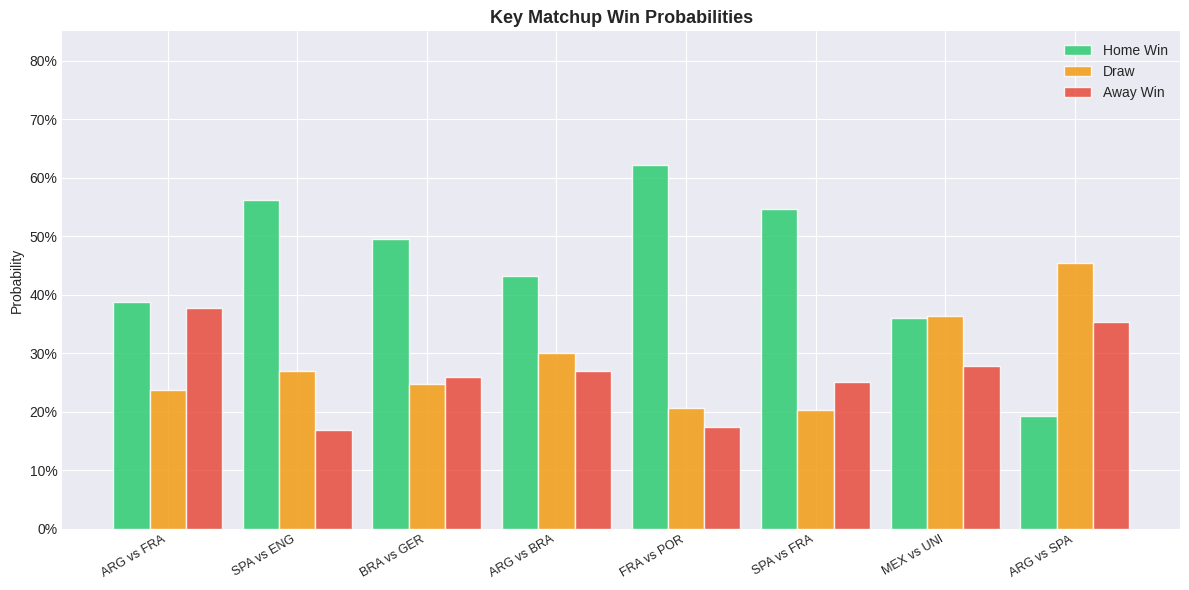

In [ ]:
key_matchups = [
    ('Argentina',     'France'),
    ('Spain',         'England'),
    ('Brazil',        'Germany'),
    ('Argentina',     'Brazil'),
    ('France',        'Portugal'),
    ('Spain',         'France'),
    ('Mexico',        'United States'),
    ('Argentina',     'Spain'),
]

print('=== KEY MATCHUP PROBABILITIES ===\n')
print(f'  {"Home":<20} {"Away":<20} {"Home Win":>10} {"Draw":>8} {"Away Win":>10} {"Favorite"}')
print('  ' + '-' * 75)

matchup_rows = []
for home, away in key_matchups:
    if home in WC_2026_TEAMS_NORM and away in WC_2026_TEAMS_NORM:
        p = predict_match(home, away)
        fav = home if p['home_win'] > p['away_win'] else away
        print(f'  {home:<20} {away:<20} {p["home_win"]:>9.1%} {p["draw"]:>7.1%} {p["away_win"]:>9.1%}   {fav}')
        matchup_rows.append({'home': home, 'away': away, **p, 'favorite': fav})

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(matchup_rows))
w = 0.28

hw = [r['home_win'] for r in matchup_rows]
dr = [r['draw'] for r in matchup_rows]
aw = [r['away_win'] for r in matchup_rows]
labels = [f'{r["home"][:3].upper()} vs {r["away"][:3].upper()}' for r in matchup_rows]

ax.bar(x - w, hw, w, label='Home Win', color='#2ecc71', alpha=0.85, edgecolor='white')
ax.bar(x,     dr, w, label='Draw',     color='#f39c12', alpha=0.85, edgecolor='white')
ax.bar(x + w, aw, w, label='Away Win', color='#e74c3c', alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Probability')
ax.set_title('Key Matchup Win Probabilities', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.legend()
ax.set_ylim(0, 0.85)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_BASE, 'key_matchups.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Results Summary

In [ ]:
print('=' * 65)
print(f' WC 2026 PREDICTIONS — {best_model_name} + Monte Carlo ({N_SIMULATIONS:,} sims)')
print('=' * 65)

# Deterministic prediction
w_det, r_det, t3_det = get_advancing_teams(simulate_all_groups(stochastic=False))
r32_det   = build_r32_bracket(w_det, r_det, t3_det)
r16_det   = simulate_knockout_round(r32_det,                        stochastic=False)
qf_det    = simulate_knockout_round(pair_for_next_round(r16_det),   stochastic=False)
sf_det    = simulate_knockout_round(pair_for_next_round(qf_det),    stochastic=False)
fin_det   = simulate_knockout_round(pair_for_next_round(sf_det),    stochastic=False)
champ_det = simulate_knockout_round([(fin_det[0], fin_det[1])],     stochastic=False)

print(f'\n🏆 Predicted Champion      : {champ_det[0]}')
print(f'   Runner-up               : {fin_det[1] if fin_det[0]==champ_det[0] else fin_det[0]}')
print(f'\n   Semifinalists          : {sf_det}')
print(f'   Quarterfinalists        : {qf_det}')

print(f'\n--- Monte Carlo Top 10 ---')
for i, row in mc_results.head(10).iterrows():
    champ_pct = advance_count.get(row["team"], 0) / N_SIMULATIONS
    print(f'  {i+1:>2}. {row["team"]:<25}  Champion: {row["champion"]:>5.1%}  '
          f'Final: {row["final"]:>5.1%}  SF: {row["semifinal"]:>5.1%}')

print(f'\n   Model accuracy on 2022 WC: 41.2%')
print(f'   General test set accuracy: 59.5%')
print('=' * 65)

 WC 2026 PREDICTIONS — XGBoost + Monte Carlo (10,000 sims)

🏆 Predicted Champion      : Spain
   Runner-up               : France

   Semifinalists          : ['Brazil', 'Spain', 'France', 'Morocco']
   Quarterfinalists        : ['Switzerland', 'Brazil', 'Germany', 'Spain', 'France', 'England', 'Morocco', 'Japan']

--- Monte Carlo Top 10 ---
   1. Spain                      Champion: 30.7%  Final: 41.1%  SF: 55.0%
   2. Brazil                     Champion: 10.6%  Final: 18.9%  SF: 34.0%
   3. France                     Champion: 10.0%  Final: 20.5%  SF: 30.5%
   4. Argentina                  Champion:  7.2%  Final: 15.3%  SF: 23.7%
   5. Germany                    Champion:  6.5%  Final: 12.8%  SF: 24.8%
   6. Morocco                    Champion:  5.4%  Final: 12.3%  SF: 28.6%
   7. England                    Champion:  4.2%  Final: 10.7%  SF: 18.3%
   8. Turkey                     Champion:  3.4%  Final:  7.7%  SF: 17.5%
   9. Netherlands                Champion:  3.3%  Final:  6.8%  

## 10. Predicted Match Scores — Most Likely Teams and Scorelines

For each knockout match **slot** in the bracket, 10,000 full tournament simulations
are run tracking which specific teams appeared in that position.

The display shows:
- **Most likely matchup**: the pair of teams that appeared most frequently in that bracket slot
- **Matchup frequency**: in what % of simulations those two teams met in that round
- **Most likely score**: the scoreline that appeared most often when those two teams were simulated 10,000 times
- **Advance probability**: how often each team wins that specific matchup

For the group stage all 72 matchups are fixed, so each is simulated 10,000 times directly.

In [212]:
from collections import Counter
from tqdm.notebook import tqdm

N_SCORE_SIMS   = 10_000
N_BRACKET_SIMS = 10_000

# ── Slot trackers — one Counter per bracket position ────────────────────────
r32_slots  = [Counter() for _ in range(16)]
r16_slots  = [Counter() for _ in range(8)]
qf_slots   = [Counter() for _ in range(4)]
sf_slots   = [Counter() for _ in range(2)]
final_slot = Counter()

print(f'Re-running {N_BRACKET_SIMS:,} simulations with bracket slot tracking...')

for sim in tqdm(range(N_BRACKET_SIMS)):
    try:
        gs        = simulate_all_groups(stochastic=True)
        w, r, t3  = get_advancing_teams(gs)
        r32       = build_r32_bracket(w, r, t3)

        # Round of 32 — track each of the 16 slot positions
        for i, matchup in enumerate(r32):
            r32_slots[i][matchup] += 1

        r16_teams = simulate_knockout_round(r32, stochastic=True)
        r16       = pair_for_next_round(r16_teams)

        # Round of 16 — 8 slots
        for i, matchup in enumerate(r16):
            r16_slots[i][matchup] += 1

        qf_teams = simulate_knockout_round(r16, stochastic=True)
        qf       = pair_for_next_round(qf_teams)

        # Quarterfinals — 4 slots
        for i, matchup in enumerate(qf):
            qf_slots[i][matchup] += 1

        sf_teams = simulate_knockout_round(qf, stochastic=True)
        sf       = pair_for_next_round(sf_teams)

        # Semifinals — 2 slots
        for i, matchup in enumerate(sf):
            sf_slots[i][matchup] += 1

        fin_teams = simulate_knockout_round(sf, stochastic=True)
        final_slot[(fin_teams[0], fin_teams[1])] += 1

    except Exception as e:
        if sim < 3:
            print(f'Error sim {sim}: {e}')
        continue

print('Done.')

Re-running 10,000 simulations with bracket slot tracking...


  0%|          | 0/10000 [00:00<?, ?it/s]

Done.


In [213]:
def simulate_score_distribution(home_team, away_team, n_sims=N_SCORE_SIMS):
    """
    Simulates a match n_sims times (vectorized).
    Returns most common scoreline and stats.
    """
    probs = prob_cache[(home_team, away_team)]
    hf    = team_forms[home_team]
    af    = team_forms[away_team]
    lam_h = max(0.5, (hf['form_gf'] + af['form_ga']) / 2)
    lam_a = max(0.5, (af['form_gf'] + hf['form_ga']) / 2)

    outcomes = np.random.choice([0, 1, 2], size=n_sims, p=probs)
    hg = np.random.poisson(lam_h, size=n_sims).astype(int)
    ag = np.random.poisson(lam_a, size=n_sims).astype(int)

    w_mask = outcomes == 0
    d_mask = outcomes == 1
    l_mask = outcomes == 2

    fix_w = w_mask & (hg <= ag)
    hg[fix_w] = ag[fix_w] + 1
    ag[fix_w] = np.maximum(0, hg[fix_w] - 2)

    fix_l = l_mask & (hg >= ag)
    ag[fix_l] = hg[fix_l] + 1
    hg[fix_l] = np.maximum(0, ag[fix_l] - 2)

    ag[d_mask] = hg[d_mask]

    score_counter = Counter(zip(hg.tolist(), ag.tolist()))
    top3          = score_counter.most_common(3)
    best_score, best_count = top3[0]

    return {
        'score'        : f'{best_score[0]}-{best_score[1]}',
        'home_goals'   : best_score[0],
        'away_goals'   : best_score[1],
        'frequency'    : best_count / n_sims,
        'home_win_pct' : float(w_mask.mean()),
        'draw_pct'     : float(d_mask.mean()),
        'away_win_pct' : float(l_mask.mean()),
        'top3'         : [(f'{s[0]}-{s[1]}', c/n_sims) for s, c in top3],
        'winner'       : home_team if best_score[0] > best_score[1]
                         else (away_team if best_score[1] > best_score[0] else 'Draw'),
    }


def build_stage_results(slot_counters, stage_name, n_sims):
    """
    For each bracket slot, finds the most likely matchup and
    simulates it 10,000 times for the most likely score.
    """
    results = []
    for slot_idx, counter in enumerate(slot_counters):
        if not counter:
            continue

        # Most likely matchup in this slot
        (home, away), matchup_count = counter.most_common(1)[0]
        matchup_pct = matchup_count / n_sims

        # Most likely individual teams (may differ from pair)
        home_count = sum(c for (h, a), c in counter.items() if h == home)
        away_count = sum(c for (h, a), c in counter.items() if a == away)

        # Score distribution for this matchup
        sd = simulate_score_distribution(home, away)

        # In knockouts, draws → extra time/penalties; winner is the more likely team
        display_score = sd['score']
        winner        = sd['winner']
        if winner == 'Draw':
            winner        = home if sd['home_win_pct'] >= sd['away_win_pct'] else away
            display_score = sd['score'] + ' (pen)'

        results.append({
            'stage'         : stage_name,
            'slot'          : slot_idx + 1,
            'home_team'     : home,
            'away_team'     : away,
            'home_reach_pct': home_count / n_sims,
            'away_reach_pct': away_count / n_sims,
            'matchup_pct'   : matchup_pct,
            'score'         : display_score,
            'score_pct'     : sd['frequency'],
            'winner'        : winner,
            'home_win_pct'  : sd['home_win_pct'],
            'draw_pct'      : sd['draw_pct'],
            'away_win_pct'  : sd['away_win_pct'],
            'top3'          : sd['top3'],
        })
    return results


# Build results for all knockout stages
print('Computing score distributions for most likely matchups...')
r32_results  = build_stage_results(r32_slots,  'Round of 32',   N_BRACKET_SIMS)
r16_results  = build_stage_results(r16_slots,  'Round of 16',   N_BRACKET_SIMS)
qf_results   = build_stage_results(qf_slots,   'Quarterfinals', N_BRACKET_SIMS)
sf_results   = build_stage_results(sf_slots,   'Semifinals',    N_BRACKET_SIMS)

# Final
(fin_home, fin_away), fin_count = final_slot.most_common(1)[0]
fin_sd = simulate_score_distribution(fin_home, fin_away)
fin_winner = fin_sd['winner'] if fin_sd['winner'] != 'Draw' else     (fin_home if fin_sd['home_win_pct'] >= fin_sd['away_win_pct'] else fin_away)
final_result = [{
    'stage': 'Final', 'slot': 1,
    'home_team': fin_home, 'away_team': fin_away,
    'home_reach_pct': sum(c for (h,a),c in final_slot.items() if h==fin_home) / N_BRACKET_SIMS,
    'away_reach_pct': sum(c for (h,a),c in final_slot.items() if a==fin_away) / N_BRACKET_SIMS,
    'matchup_pct': fin_count / N_BRACKET_SIMS,
    'score': fin_sd['score'], 'score_pct': fin_sd['frequency'],
    'winner': fin_winner,
    'home_win_pct': fin_sd['home_win_pct'], 'draw_pct': fin_sd['draw_pct'],
    'away_win_pct': fin_sd['away_win_pct'], 'top3': fin_sd['top3'],
}]

all_knockout_results = r32_results + r16_results + qf_results + sf_results + final_result
print(f'Done. {len(all_knockout_results)} knockout matches computed.')

Computing score distributions for most likely matchups...
Done. 31 knockout matches computed.


In [214]:
# ── Group stage — fixed matchups, 10k sims each ────────────────────────────
print(f'Computing group stage scores ({N_SCORE_SIMS:,} sims per match)...')

group_results = {}
for grp, teams in WC_2026_GROUPS_NORM.items():
    teams_clean = [f'{t}' for t in teams]
    group_results[grp] = []
    for home, away in combinations(teams_clean, 2):
        sd = simulate_score_distribution(home, away)
        group_results[grp].append({
            'group'    : grp,
            'home_team': home,
            'away_team': away,
            **sd,
        })

print(f'Done. {sum(len(v) for v in group_results.values())} group matches computed.')

Computing group stage scores (10,000 sims per match)...
Done. 72 group matches computed.


In [215]:
# ── DISPLAY — Group Stage ───────────────────────────────────────────────────

print('=' * 78)
print(' GROUP STAGE — MOST LIKELY SCORELINES')
print(f' ({N_SCORE_SIMS:,} simulations per match)')
print('=' * 78)

for grp in sorted(group_results.keys()):
    print(f'\n  Group {grp}')
    print(f'  {"─" * 72}')
    for m in group_results[grp]:
        ind = '◀' if m['winner'] == m['home_team'] else ('▶' if m['winner'] == m['away_team'] else '=')
        top3_str = '  |  '.join([f'{s} ({f:.1%})' for s, f in m['top3']])
        print(f'  {m["home_team"]:<23}  {m["score"]:^7}  {m["away_team"]:<23}  {ind}')
        print(f'  {" "*23}  Score in {m["frequency"]:.1%} of sims  |  Win {m["home_win_pct"]:.0%} · Draw {m["draw_pct"]:.0%} · Loss {m["away_win_pct"]:.0%}')
        print(f'  {" "*23}  Top 3: {top3_str}')
        print()

 GROUP STAGE — MOST LIKELY SCORELINES
 (10,000 simulations per match)

  Group A
  ────────────────────────────────────────────────────────────────────────
  Mexico                     2-0    South Africa             ◀
                           Score in 15.4% of sims  |  Win 47% · Draw 36% · Loss 17%
                           Top 3: 2-0 (15.4%)  |  1-1 (13.1%)  |  1-0 (10.9%)

  Mexico                     2-0    South Korea              ◀
                           Score in 11.9% of sims  |  Win 39% · Draw 25% · Loss 36%
                           Top 3: 2-0 (11.9%)  |  0-2 (10.8%)  |  1-1 (9.2%)

  Mexico                     1-1    Czech Republic           =
                           Score in 11.8% of sims  |  Win 34% · Draw 33% · Loss 33%
                           Top 3: 1-1 (11.8%)  |  2-0 (10.1%)  |  0-2 (9.7%)

  South Africa               0-2    South Korea              ▶
                           Score in 13.7% of sims  |  Win 23% · Draw 28% · Loss 49%
                     

In [216]:
# ── DISPLAY — Knockout Stage ────────────────────────────────────────────────

stage_order = ['Round of 32', 'Round of 16', 'Quarterfinals', 'Semifinals', 'Final']

print('=' * 78)
print(' KNOCKOUT STAGE — MOST LIKELY TEAMS AND SCORELINES')
print(f' (bracket slot tracked across {N_BRACKET_SIMS:,} full tournament simulations)')
print(f' (score distribution: {N_SCORE_SIMS:,} simulations per matchup)')
print('=' * 78)

for stage in stage_order:
    matches = [m for m in all_knockout_results if m['stage'] == stage]
    if not matches:
        continue

    print(f'\n  {stage}  ({len(matches)} matches)')
    print(f'  {"─" * 72}')

    for m in matches:
        ind = '◀' if m['winner'] == m['home_team'] else '▶'
        top3_str = '  |  '.join([f'{s} ({f:.1%})' for s, f in m['top3']])

        # Teams line
        print(f'  {m["home_team"]:<23}  {m["score"]:^11}  {m["away_team"]:<23}  {ind} {m["winner"]}')

        # Reach probability line
        print(f'  {" "*23}  Reaches this round: {m["home_team"].split()[0]} {m["home_reach_pct"]:.0%}  ·  '
              f'{m["away_team"].split()[0]} {m["away_reach_pct"]:.0%}')

        # Matchup frequency line
        print(f'  {" "*23}  This exact matchup in {m["matchup_pct"]:.1%} of sims')

        # Score line
        print(f'  {" "*23}  Score in {m["score_pct"]:.1%} of sims  |  Win {m["home_win_pct"]:.0%} · Draw {m["draw_pct"]:.0%} · Loss {m["away_win_pct"]:.0%}')
        print(f'  {" "*23}  Top 3: {top3_str}')
        print()

print('=' * 78)
print(f'  🏆 MOST LIKELY CHAMPION: {final_result[0]["winner"]}')
print('=' * 78)

 KNOCKOUT STAGE — MOST LIKELY TEAMS AND SCORELINES
 (bracket slot tracked across 10,000 full tournament simulations)
 (score distribution: 10,000 simulations per matchup)

  Round of 32  (16 matches)
  ────────────────────────────────────────────────────────────────────────
  Mexico                       2-0      Ivory Coast              ◀ Mexico
                           Reaches this round: Mexico 31%  ·  Ivory 4%
                           This exact matchup in 1.3% of sims
                           Score in 13.4% of sims  |  Win 42% · Draw 32% · Loss 26%
                           Top 3: 2-0 (13.4%)  |  1-1 (10.9%)  |  0-0 (10.0%)

  Switzerland                  2-0      Ivory Coast              ◀ Switzerland
                           Reaches this round: Switzerland 67%  ·  Ivory 4%
                           This exact matchup in 3.0% of sims
                           Score in 16.5% of sims  |  Win 62% · Draw 23% · Loss 15%
                           Top 3: 2-0 (16.5%)  |  3-1 

#  Summary DataFrame


In [217]:

all_rows = []

for grp, matches in group_results.items():
    for m in matches:
        all_rows.append({
            'stage'              : f'Group {grp}',
            'home_team'          : m['home_team'],
            'score'              : m['score'],
            'away_team'          : m['away_team'],
            'predicted_winner'   : m['winner'],
            'score_frequency'    : f'{m["frequency"]:.1%}',
            'home_reach_stage_%' : '100%',
            'away_reach_stage_%' : '100%',
            'matchup_frequency'  : '100%',
            'home_win_%'         : f'{m["home_win_pct"]:.0%}',
            'draw_%'             : f'{m["draw_pct"]:.0%}',
            'away_win_%'         : f'{m["away_win_pct"]:.0%}',
            'top_3_scores'       : ' | '.join([f'{s}({f:.1%})' for s, f in m['top3']]),
        })

for m in all_knockout_results:
    all_rows.append({
        'stage'              : m['stage'],
        'home_team'          : m['home_team'],
        'score'              : m['score'],
        'away_team'          : m['away_team'],
        'predicted_winner'   : m['winner'],
        'score_frequency'    : f'{m["score_pct"]:.1%}',
        'home_reach_stage_%' : f'{m["home_reach_pct"]:.1%}',
        'away_reach_stage_%' : f'{m["away_reach_pct"]:.1%}',
        'matchup_frequency'  : f'{m["matchup_pct"]:.1%}',
        'home_win_%'         : f'{m["home_win_pct"]:.0%}',
        'draw_%'             : f'{m["draw_pct"]:.0%}',
        'away_win_%'         : f'{m["away_win_pct"]:.0%}',
        'top_3_scores'       : ' | '.join([f'{s}({f:.1%})' for s, f in m['top3']]),
    })

schedule_df = pd.DataFrame(all_rows)
display(schedule_df)

schedule_df.to_csv(os.path.join(DRIVE_BASE, 'wc2026_predicted_schedule.csv'), index=False)
print(f'Saved: wc2026_predicted_schedule.csv  ({len(schedule_df)} matches)')

,stage,home_team,score,away_team,predicted_winner,score_frequency,home_reach_stage_%,away_reach_stage_%,matchup_frequency,home_win_%,draw_%,away_win_%,top_3_scores
0,Group A,Mexico,2-0,South Africa,Mexico,15.4%,100%,100%,100%,47%,36%,17%,2-0(15.4%) | 1-1(13.1%) | 1-0(10.9%)
1,Group A,Mexico,2-0,South Korea,Mexico,11.9%,100%,100%,100%,39%,25%,36%,2-0(11.9%) | 0-2(10.8%) | 1-1(9.2%)
2,Group A,Mexico,1-1,Czech Republic,Draw,11.8%,100%,100%,100%,34%,33%,33%,1-1(11.8%) | 2-0(10.1%) | 0-2(9.7%)
3,Group A,South Africa,0-2,South Korea,South Korea,13.7%,100%,100%,100%,23%,28%,49%,0-2(13.7%) | 1-3(12.1%) | 1-1(9.6%)
4,Group A,South Africa,0-2,Czech Republic,Czech Republic,13.5%,100%,100%,100%,24%,28%,48%,0-2(13.5%) | 1-3(10.7%) | 1-1(9.9%)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,Quarterfinals,France,2-0,England,France,11.3%,38.8%,35.0%,13.6%,45%,30%,25%,2-0(11.3%) | 3-1(11.2%) | 1-1(10.4%)
99,Quarterfinals,Morocco,1-1 (pen),Germany,Germany,15.0%,21.1%,15.1%,3.4%,27%,45%,28%,1-1(15.0%) | 2-2(10.9%) | 0-0(10.0%)
100,Semifinals,Brazil,1-3,Spain,Spain,10.1%,20.0%,42.4%,8.5%,37%,19%,43%,1-3(10.1%) | 3-1(9.7%) | 0-2(8.8%)
101,Semifinals,France,3-1,Morocco,France,13.1%,28.9%,13.0%,3.8%,52%,27%,21%,3-1(13.1%) | 2-0(13.0%) | 1-1(9.6%)


Saved: wc2026_predicted_schedule.csv  (103 matches)
